# Embeddings Exploration Notebook

This notebook is a practical, end-to-end workspace for comparing tracks in `music/aries-mix`.

What you can do here:
1. Build MAEST, DEAM, and chroma representations.
2. Visualize the set in low-dimensional spaces (PCA / PaCMAP).
3. Inspect transition smoothness, key relationships, and harmonic similarity.

Suggested run order: top to bottom for a full refresh of all derived files in `data/`.



In [3]:
from __future__ import annotations

import csv
import json
import re
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D
from essentia.standard import MonoLoader

try:
    import pacmap
except ImportError:
    pacmap = None

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "music").exists() and (PROJECT_ROOT.parent / "music").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))


def to_project_relpath(path: str | Path) -> str:
    resolved = Path(path).expanduser().resolve()
    try:
        return str(resolved.relative_to(PROJECT_ROOT))
    except ValueError:
        return str(resolved)


from djprojectexploration.maest_embedding_extractor import (
    DEFAULT_MODEL_FILENAME,
    DEFAULT_OUTPUT_NODE,
    extract_embedding,
)
from djprojectexploration.deam_valence_arousal import (
    predict_deam_valence_arousal_musicnn,
    save_deam_prediction_json,
)
from djprojectexploration.chroma_embedding import generate_chroma_embedding
from djprojectexploration.harmonic_compatibility import (
    PITCH_CLASS_C_ORDER,
    build_fifth_kernel,
    pairwise_fifth_aware_similarity_matrix,
)

print(f"Project root: {PROJECT_ROOT}")



Project root: /Users/josephdaher/Git Repositories/djprojectexploration


In [4]:
MUSIC_DIR = PROJECT_ROOT / "music" / "aries-mix"
DATA_DIR = PROJECT_ROOT / "data" / "maest_embeddings"
MODELS_DIR = PROJECT_ROOT / "models"
MODEL_FILE = MODELS_DIR / DEFAULT_MODEL_FILENAME
OUTPUT_NODE = DEFAULT_OUTPUT_NODE

DATA_DIR.mkdir(parents=True, exist_ok=True)

mp3_files = sorted(MUSIC_DIR.glob("*.mp3"))
if not mp3_files:
    raise FileNotFoundError(f"No .mp3 files found in {MUSIC_DIR}")

if not MODEL_FILE.exists():
    candidates = sorted(MODELS_DIR.glob("discogs-maest*.pb"))
    if not candidates:
        raise FileNotFoundError(
            f"Model file not found: {MODEL_FILE}\n"
            f"No fallback discogs-maest*.pb model found in {MODELS_DIR}"
        )
    MODEL_FILE = candidates[0]

print(f"Detected {len(mp3_files)} mp3 files in {MUSIC_DIR}")
print(f"Using config: MAEST model: {MODEL_FILE}")
print(f"Output node: {OUTPUT_NODE}")




Found 25 mp3 files in /Users/josephdaher/Git Repositories/djprojectexploration/music/aries-mix
Using MAEST model: /Users/josephdaher/Git Repositories/djprojectexploration/models/discogs-maest-30s-pw-519l-2.pb
Output node: PartitionedCall/Identity_7


In [5]:
records = []

for audio_file in mp3_files:
    embedding, raw_shape, reduction = extract_embedding(audio_file, MODEL_FILE, OUTPUT_NODE)

    payload = {
        "title": "MAEST Embedding (Essentia)",
        "filename": audio_file.name,
        "audio_file": to_project_relpath(audio_file),
        "embedding_type": "maest",
        "model_name": MODEL_FILE.stem,
        "model_file": to_project_relpath(MODEL_FILE),
        "output_node": OUTPUT_NODE,
        "reduction": reduction,
        "raw_prediction_shape": list(raw_shape),
        "embedding_dimension": int(embedding.shape[0]),
        "embedding": embedding.tolist(),
    }

    per_track_file = DATA_DIR / f"{audio_file.stem}_maest_embedding.json"
    with per_track_file.open("w", encoding="utf-8") as f:
        json.dump(payload, f, indent=4)

    records.append({
        "filename": audio_file.name,
        "embedding": embedding.astype(np.float32),
        "raw_prediction_shape": list(raw_shape),
        "reduction": reduction,
    })

    print(f"Saved output: {per_track_file.name} (dim={payload['embedding_dimension']})")

print(f"\nSaved {len(records)} per-track JSON files in {DATA_DIR}")




[   INFO   ] TensorflowPredict: Successfully loaded graph file: `/Users/josephdaher/Git Repositories/djprojectexploration/models/discogs-maest-30s-pw-519l-2.pb`
I0000 00:00:1774758162.227475 3891622 mlir_graph_optimization_pass.cc:425] MLIR V1 optimization pass is not enabled


Saved access_maest_embedding.json (dim=768)


[   INFO   ] TensorflowPredict: Successfully loaded graph file: `/Users/josephdaher/Git Repositories/djprojectexploration/models/discogs-maest-30s-pw-519l-2.pb`


Saved apex_maest_embedding.json (dim=768)


[   INFO   ] TensorflowPredict: Successfully loaded graph file: `/Users/josephdaher/Git Repositories/djprojectexploration/models/discogs-maest-30s-pw-519l-2.pb`


...

[   INFO   ] TensorflowPredict: Successfully loaded graph file: `/Users/josephdaher/Git Repositories/djprojectexploration/models/discogs-maest-30s-pw-519l-2.pb`


Saved warrior_maest_embedding.json (dim=768)


[   INFO   ] TensorflowPredict: Successfully loaded graph file: `/Users/josephdaher/Git Repositories/djprojectexploration/models/discogs-maest-30s-pw-519l-2.pb`


Saved water_maest_embedding.json (dim=768)
Saved yesman_maest_embedding.json (dim=768)

Saved 25 per-track JSON files in /Users/josephdaher/Git Repositories/djprojectexploration/data/maest_embeddings


[   INFO   ] TensorflowPredict: Successfully loaded graph file: `/Users/josephdaher/Git Repositories/djprojectexploration/models/discogs-maest-30s-pw-519l-2.pb`


In [6]:
filenames = [r["filename"] for r in records]
embeddings = np.vstack([r["embedding"] for r in records]).astype(np.float32)

npz_path = DATA_DIR / "maest_embeddings.npz"
np.savez_compressed(
    npz_path,
    filenames=np.array(filenames),
    embeddings=embeddings,
)

manifest = {
    "title": "MAEST Embedding Collection",
    "model_file": to_project_relpath(MODEL_FILE),
    "output_node": OUTPUT_NODE,
    "num_tracks": len(records),
    "embedding_dimension": int(embeddings.shape[1]),
    "tracks": [
        {
            "filename": r["filename"],
            "reduction": r["reduction"],
            "raw_prediction_shape": r["raw_prediction_shape"],
            "per_track_embedding_file": to_project_relpath(DATA_DIR / f"{Path(r['filename']).stem}_maest_embedding.json"),
        }
        for r in records
    ],
}

manifest_path = DATA_DIR / "maest_embeddings_manifest.json"
with manifest_path.open("w", encoding="utf-8") as f:
    json.dump(manifest, f, indent=4)

print(f"Saved output: aggregate matrix: {npz_path}")
print(f"Saved output: manifest: {manifest_path}")
print(f"Embedding matrix shape: {embeddings.shape}")




Saved aggregate matrix: /Users/josephdaher/Git Repositories/djprojectexploration/data/maest_embeddings/maest_embeddings.npz
Saved manifest: /Users/josephdaher/Git Repositories/djprojectexploration/data/maest_embeddings/maest_embeddings_manifest.json
Embedding matrix shape: (25, 768)


Loaded track order from: /Users/josephdaher/Git Repositories/djprojectexploration/music/aries-mix/aries_mix_tracks.csv
Matched tracks from CSV against embeddings: 25
CSV tracks not embedded: 0
Embedded tracks not in CSV: 0
Genres used for coloring: chillout, melodic techno, progressive house, psytrance, tech house, tech trance, techno, trance


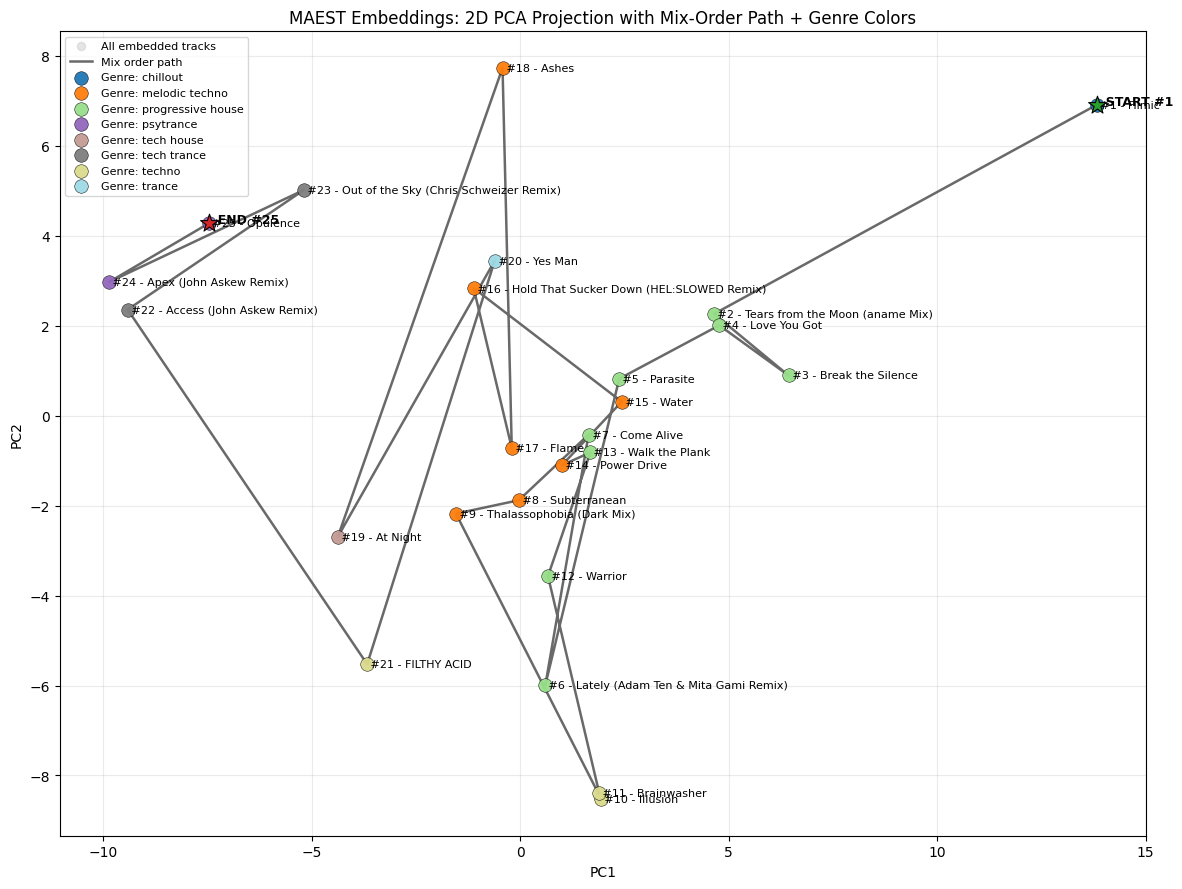

Saved plot: /Users/josephdaher/Git Repositories/djprojectexploration/data/maest_embeddings/maest_embeddings_pca_plot.png


In [7]:
if embeddings.shape[0] < 2:
    raise ValueError("Need at least 2 tracks to build a 2D projection.")

centered = embeddings - embeddings.mean(axis=0, keepdims=True)
_u, _s, vt = np.linalg.svd(centered, full_matrices=False)
coords = centered @ vt[:2].T
if coords.shape[1] < 2:
    coords = np.pad(coords, ((0, 0), (0, 2 - coords.shape[1])), mode="constant")

fig, ax = plt.subplots(figsize=(12, 9))

# Base layer: all tracks as light points
ax.scatter(
    coords[:, 0],
    coords[:, 1],
    s=35,
    color="#c7c7c7",
    alpha=0.45,
    label="All embedded tracks",
)

tracklist_csv = PROJECT_ROOT / "music" / "aries-mix" / "aries_mix_tracks.csv"
filename_to_idx = {name.lower(): i for i, name in enumerate(filenames)}
ordered_matches = []
csv_mp3_names = set()

if tracklist_csv.exists():
    with tracklist_csv.open("r", encoding="utf-8", newline="") as f:
        reader = csv.DictReader(f)
        for row in reader:
            track_num_raw = (row.get("track_number") or row.get("#") or "").strip()
            mp3_name = (row.get("mp3_name") or "").strip().lower()
            title = (row.get("title") or "").strip()
            genre = (row.get("genre") or "").strip()

            if not track_num_raw or not mp3_name:
                continue

            csv_mp3_names.add(mp3_name)

            try:
                track_num = int(track_num_raw)
            except ValueError:
                continue

            idx = filename_to_idx.get(mp3_name)
            if idx is not None:
                ordered_matches.append(
                    {
                        "track_num": track_num,
                        "idx": idx,
                        "mp3_name": mp3_name,
                        "title": title,
                        "genre": genre if genre else "Unknown",
                    }
                )

ordered_matches.sort(key=lambda x: x["track_num"])

if ordered_matches:
    order_idx = [item["idx"] for item in ordered_matches]
    path_coords = coords[order_idx]

    # Draw trajectory line in track-number order
    ax.plot(
        path_coords[:, 0],
        path_coords[:, 1],
        color="#444444",
        linewidth=1.8,
        alpha=0.8,
        label="Mix order path",
        zorder=2,
    )

    # Color points by genre
    genres = sorted({item["genre"] for item in ordered_matches}, key=lambda g: g.lower())
    cmap = plt.get_cmap("tab20", max(1, len(genres)))
    genre_to_color = {genre: cmap(i) for i, genre in enumerate(genres)}

    for genre in genres:
        genre_points = [item for item in ordered_matches if item["genre"] == genre]
        genre_idx = [item["idx"] for item in genre_points]
        genre_coords = coords[genre_idx]
        ax.scatter(
            genre_coords[:, 0],
            genre_coords[:, 1],
            s=95,
            color=genre_to_color[genre],
            edgecolor="black",
            linewidth=0.35,
            alpha=0.95,
            label=f"Genre: {genre}",
            zorder=3,
        )

    # Label points with "#<track> - <song title>"
    for item in ordered_matches:
        label_title = item["title"] if item["title"] else Path(item["mp3_name"]).stem
        ax.text(
            coords[item["idx"], 0],
            coords[item["idx"], 1],
            f" #{item['track_num']} - {label_title}",
            fontsize=8,
            va="center",
        )

    # Highlight start/end
    first = ordered_matches[0]
    last = ordered_matches[-1]
    ax.scatter(
        coords[first["idx"], 0],
        coords[first["idx"], 1],
        s=180,
        marker="*",
        color="#2ca02c",
        edgecolor="black",
        linewidth=0.8,
        zorder=5,
    )
    ax.scatter(
        coords[last["idx"], 0],
        coords[last["idx"], 1],
        s=180,
        marker="*",
        color="#d62728",
        edgecolor="black",
        linewidth=0.8,
        zorder=5,
    )
    ax.text(
        coords[first["idx"], 0],
        coords[first["idx"], 1],
        f"  START #{first['track_num']}",
        fontsize=9,
        weight="bold",
    )
    ax.text(
        coords[last["idx"], 0],
        coords[last["idx"], 1],
        f"  END #{last['track_num']}",
        fontsize=9,
        weight="bold",
    )

    embedding_name_set = set(filename_to_idx.keys())
    unmatched_csv = sorted(csv_mp3_names - embedding_name_set)
    unmatched_embeddings = sorted(embedding_name_set - csv_mp3_names)

    print(f"Loaded track order from: {tracklist_csv}")
    print(f"Matched tracks from CSV against embeddings: {len(ordered_matches)}")
    print(f"CSV tracks not embedded: {len(unmatched_csv)}")
    print(f"Embedded tracks not in CSV: {len(unmatched_embeddings)}")
    print(f"Genres used for coloring: {', '.join(genres)}")
else:
    # Fallback: label all points by file stem if no CSV matches are found
    for i, name in enumerate(filenames):
        ax.text(coords[i, 0], coords[i, 1], f" {Path(name).stem}", fontsize=9, va="center")
    print("No CSV track-order matches found; fallback labels use filename stems.")

ax.set_title("MAEST Embeddings: 2D PCA Projection with Mix-Order Path + Genre Colors")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.grid(alpha=0.25)
ax.legend(loc="best", fontsize=8)

plot_path = DATA_DIR / "maest_embeddings_pca_plot.png"
fig.tight_layout()
fig.savefig(plot_path, dpi=220)
plt.show()

print(f"Saved plot: {plot_path}")



### MAEST PaCMAP Projection (Mix Path)

Alternative to PCA using PaCMAP.

Use this when you want a non-linear 2D view that can preserve local neighborhoods better than PCA.



Sample size is smaller than the total number of assigned points, n_neighbors, n_MN, n_FP would be reorganized


Loaded track order from: /Users/josephdaher/Git Repositories/djprojectexploration/music/aries-mix/aries_mix_tracks.csv
Matched tracks from CSV against embeddings: 25
CSV tracks not embedded: 0
Embedded tracks not in CSV: 0
Genres used for coloring: chillout, melodic techno, progressive house, psytrance, tech house, tech trance, techno, trance


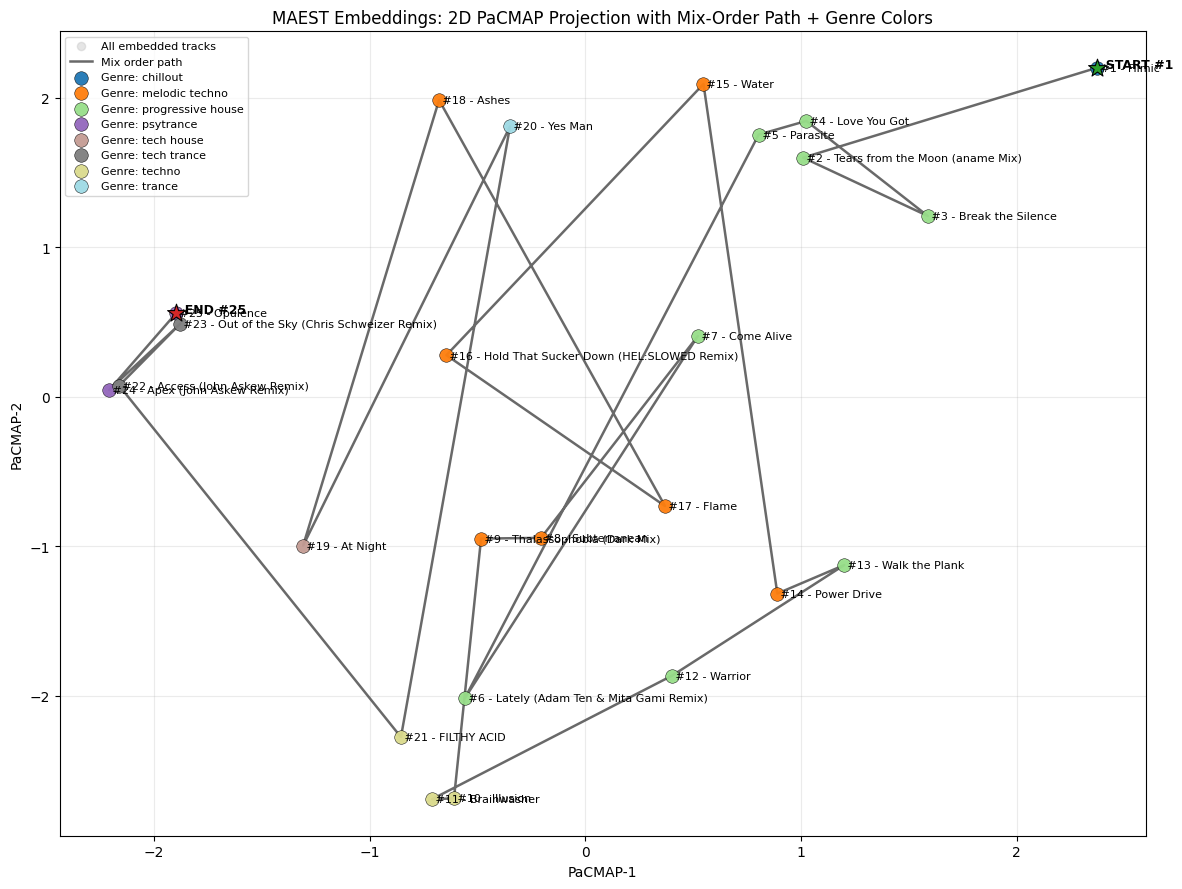

Saved PaCMAP plot: /Users/josephdaher/Git Repositories/djprojectexploration/data/maest_embeddings/maest_embeddings_pacmap_plot.png


In [23]:
if pacmap is None:
    raise ImportError("PaCMAP is not installed in this environment. Install with: pip install pacmap")

if embeddings.shape[0] < 2:
    raise ValueError("Need at least 2 tracks to build a 2D projection.")

reducer = pacmap.PaCMAP(
    n_components=2,
    n_neighbors=min(10, max(2, embeddings.shape[0] - 1)),
    MN_ratio=0.5,
    FP_ratio=1.5,
    random_state=7777,
)
coords_pacmap = reducer.fit_transform(embeddings.astype(np.float32))

fig, ax = plt.subplots(figsize=(12, 9))

# Base layer: all tracks as light points
ax.scatter(
    coords_pacmap[:, 0],
    coords_pacmap[:, 1],
    s=35,
    color="#c7c7c7",
    alpha=0.45,
    label="All embedded tracks",
)

tracklist_csv = PROJECT_ROOT / "music" / "aries-mix" / "aries_mix_tracks.csv"
filename_to_idx = {name.lower(): i for i, name in enumerate(filenames)}
ordered_matches = []
csv_mp3_names = set()

if tracklist_csv.exists():
    with tracklist_csv.open("r", encoding="utf-8", newline="") as f:
        reader = csv.DictReader(f)
        for row in reader:
            track_num_raw = (row.get("track_number") or row.get("#") or "").strip()
            mp3_name = (row.get("mp3_name") or "").strip().lower()
            title = (row.get("title") or "").strip()
            genre = (row.get("genre") or "").strip()

            if not track_num_raw or not mp3_name:
                continue

            csv_mp3_names.add(mp3_name)

            try:
                track_num = int(track_num_raw)
            except ValueError:
                continue

            idx = filename_to_idx.get(mp3_name)
            if idx is not None:
                ordered_matches.append(
                    {
                        "track_num": track_num,
                        "idx": idx,
                        "mp3_name": mp3_name,
                        "title": title,
                        "genre": genre if genre else "Unknown",
                    }
                )

ordered_matches.sort(key=lambda x: x["track_num"])

if ordered_matches:
    order_idx = [item["idx"] for item in ordered_matches]
    path_coords = coords_pacmap[order_idx]

    # Draw trajectory line in track-number order
    ax.plot(
        path_coords[:, 0],
        path_coords[:, 1],
        color="#444444",
        linewidth=1.8,
        alpha=0.8,
        label="Mix order path",
        zorder=2,
    )

    # Color points by genre
    genres = sorted({item["genre"] for item in ordered_matches}, key=lambda g: g.lower())
    cmap = plt.get_cmap("tab20", max(1, len(genres)))
    genre_to_color = {genre: cmap(i) for i, genre in enumerate(genres)}

    for genre in genres:
        genre_points = [item for item in ordered_matches if item["genre"] == genre]
        genre_idx = [item["idx"] for item in genre_points]
        genre_coords = coords_pacmap[genre_idx]
        ax.scatter(
            genre_coords[:, 0],
            genre_coords[:, 1],
            s=95,
            color=genre_to_color[genre],
            edgecolor="black",
            linewidth=0.35,
            alpha=0.95,
            label=f"Genre: {genre}",
            zorder=3,
        )

    # Label points with "#<track> - <song title>"
    for item in ordered_matches:
        label_title = item["title"] if item["title"] else Path(item["mp3_name"]).stem
        ax.text(
            coords_pacmap[item["idx"], 0],
            coords_pacmap[item["idx"], 1],
            f" #{item['track_num']} - {label_title}",
            fontsize=8,
            va="center",
        )

    # Highlight start/end
    first = ordered_matches[0]
    last = ordered_matches[-1]
    ax.scatter(
        coords_pacmap[first["idx"], 0],
        coords_pacmap[first["idx"], 1],
        s=180,
        marker="*",
        color="#2ca02c",
        edgecolor="black",
        linewidth=0.8,
        zorder=5,
    )
    ax.scatter(
        coords_pacmap[last["idx"], 0],
        coords_pacmap[last["idx"], 1],
        s=180,
        marker="*",
        color="#d62728",
        edgecolor="black",
        linewidth=0.8,
        zorder=5,
    )
    ax.text(
        coords_pacmap[first["idx"], 0],
        coords_pacmap[first["idx"], 1],
        f"  START #{first['track_num']}",
        fontsize=9,
        weight="bold",
    )
    ax.text(
        coords_pacmap[last["idx"], 0],
        coords_pacmap[last["idx"], 1],
        f"  END #{last['track_num']}",
        fontsize=9,
        weight="bold",
    )

    embedding_name_set = set(filename_to_idx.keys())
    unmatched_csv = sorted(csv_mp3_names - embedding_name_set)
    unmatched_embeddings = sorted(embedding_name_set - csv_mp3_names)

    print(f"Loaded track order from: {tracklist_csv}")
    print(f"Matched tracks from CSV against embeddings: {len(ordered_matches)}")
    print(f"CSV tracks not embedded: {len(unmatched_csv)}")
    print(f"Embedded tracks not in CSV: {len(unmatched_embeddings)}")
    print(f"Genres used for coloring: {', '.join(genres)}")
else:
    for i, name in enumerate(filenames):
        ax.text(coords_pacmap[i, 0], coords_pacmap[i, 1], f" {Path(name).stem}", fontsize=9, va="center")
    print("No CSV track-order matches found; fallback labels use filename stems.")

ax.set_title("MAEST Embeddings: 2D PaCMAP Projection with Mix-Order Path + Genre Colors")
ax.set_xlabel("PaCMAP-1")
ax.set_ylabel("PaCMAP-2")
ax.grid(alpha=0.25)
ax.legend(loc="best", fontsize=8)

plot_path_pacmap = DATA_DIR / "maest_embeddings_pacmap_plot.png"
fig.tight_layout()
fig.savefig(plot_path_pacmap, dpi=220)
plt.show()

print(f"Saved PaCMAP plot: {plot_path_pacmap}")



## DEAM Valence / Arousal

Predict emotional coordinates (valence + arousal) for each track,
then inspect both aggregate and per-segment behavior.



In [9]:
DEAM_DATA_DIR = PROJECT_ROOT / "data" / "deam_valence_arousal"
DEAM_DATA_DIR.mkdir(parents=True, exist_ok=True)

MUSICNN_MODEL_FILE = MODELS_DIR / "msd-musicnn-1.pb"
DEAM_MODEL_FILE = MODELS_DIR / "deam-msd-musicnn-2.pb"

if not MUSICNN_MODEL_FILE.exists():
    candidates = sorted(MODELS_DIR.glob("msd-musicnn*.pb"))
    if not candidates:
        candidates = sorted(MODELS_DIR.glob("*musicnn*.pb"))
    if not candidates:
        raise FileNotFoundError(
            f"MusicNN embedding model not found. Expected {MUSICNN_MODEL_FILE}\n"
            f"Add an msd-musicnn .pb file to {MODELS_DIR}."
        )
    MUSICNN_MODEL_FILE = candidates[0]

if not DEAM_MODEL_FILE.exists():
    candidates = sorted(MODELS_DIR.glob("deam-msd-musicnn*.pb"))
    if not candidates:
        candidates = sorted(MODELS_DIR.glob("deam*musicnn*.pb"))
    if not candidates:
        raise FileNotFoundError(
            f"DEAM regression model not found. Expected {DEAM_MODEL_FILE}\n"
            f"Add a deam-msd-musicnn .pb file to {MODELS_DIR}."
        )
    DEAM_MODEL_FILE = candidates[0]

print(f"Using config: MusicNN embedding model: {MUSICNN_MODEL_FILE}")
print(f"Using config: DEAM regression model: {DEAM_MODEL_FILE}")
print(f"DEAM outputs directory: {DEAM_DATA_DIR}")




Using MusicNN embedding model: /Users/josephdaher/Git Repositories/djprojectexploration/models/msd-musicnn-1.pb
Using DEAM regression model: /Users/josephdaher/Git Repositories/djprojectexploration/models/deam-msd-musicnn-2.pb
DEAM outputs directory: /Users/josephdaher/Git Repositories/djprojectexploration/data/deam_valence_arousal


In [10]:
deam_rows = []

for audio_file in mp3_files:
    prediction = predict_deam_valence_arousal_musicnn(
        audio_file=audio_file,
        embedding_model_file=MUSICNN_MODEL_FILE,
        regression_model_file=DEAM_MODEL_FILE,
    )

    output_json = DEAM_DATA_DIR / f"{audio_file.stem}_deam_valence_arousal.json"
    save_deam_prediction_json(prediction, output_json)

    track = prediction["track_prediction"]
    row = {
        "filename": audio_file.name,
        "valence": float(track["valence"]),
        "arousal": float(track["arousal"]),
        "valence_std": float(track["valence_std"]),
        "arousal_std": float(track["arousal_std"]),
        "num_segments": int(track["num_segments"]),
        "prediction_file": to_project_relpath(output_json),
    }
    deam_rows.append(row)

    print(
        f"{audio_file.name}: valence={row['valence']:.3f}, "
        f"arousal={row['arousal']:.3f}, segments={row['num_segments']}"
    )

summary_json_path = DEAM_DATA_DIR / "deam_track_predictions.json"
with summary_json_path.open("w", encoding="utf-8") as f:
    json.dump({"tracks": deam_rows}, f, indent=4)

summary_csv_path = DEAM_DATA_DIR / "deam_track_predictions.csv"
with summary_csv_path.open("w", newline="", encoding="utf-8") as f:
    writer = csv.DictWriter(
        f,
        fieldnames=[
            "filename",
            "valence",
            "arousal",
            "valence_std",
            "arousal_std",
            "num_segments",
            "prediction_file",
        ],
    )
    writer.writeheader()
    writer.writerows(deam_rows)

print(f"\nSaved DEAM summary JSON: {summary_json_path}")
print(f"Saved output: DEAM summary CSV: {summary_csv_path}")




[   INFO   ] TensorflowPredict: Successfully loaded graph file: `/Users/josephdaher/Git Repositories/djprojectexploration/models/msd-musicnn-1.pb`
[   INFO   ] TensorflowPredict: Successfully loaded graph file: `/Users/josephdaher/Git Repositories/djprojectexploration/models/deam-msd-musicnn-2.pb`


access.mp3: valence=7.224, arousal=5.292, segments=327


[   INFO   ] TensorflowPredict: Successfully loaded graph file: `/Users/josephdaher/Git Repositories/djprojectexploration/models/msd-musicnn-1.pb`
[   INFO   ] TensorflowPredict: Successfully loaded graph file: `/Users/josephdaher/Git Repositories/djprojectexploration/models/deam-msd-musicnn-2.pb`


apex.mp3: valence=7.463, arousal=5.145, segments=266


[   INFO   ] TensorflowPredict: Successfully loaded graph file: `/Users/josephdaher/Git Repositories/djprojectexploration/models/msd-musicnn-1.pb`
[   INFO   ] TensorflowPredict: Successfully loaded graph file: `/Users/josephdaher/Git Repositories/djprojectexploration/models/deam-msd-musicnn-2.pb`


...

[   INFO   ] TensorflowPredict: Successfully loaded graph file: `/Users/josephdaher/Git Repositories/djprojectexploration/models/msd-musicnn-1.pb`
[   INFO   ] TensorflowPredict: Successfully loaded graph file: `/Users/josephdaher/Git Repositories/djprojectexploration/models/deam-msd-musicnn-2.pb`


warrior.mp3: valence=6.349, arousal=6.804, segments=307


[   INFO   ] TensorflowPredict: Successfully loaded graph file: `/Users/josephdaher/Git Repositories/djprojectexploration/models/msd-musicnn-1.pb`
[   INFO   ] TensorflowPredict: Successfully loaded graph file: `/Users/josephdaher/Git Repositories/djprojectexploration/models/deam-msd-musicnn-2.pb`


water.mp3: valence=5.989, arousal=5.954, segments=171
yesman.mp3: valence=6.677, arousal=5.529, segments=261

Saved DEAM summary JSON: /Users/josephdaher/Git Repositories/djprojectexploration/data/deam_valence_arousal/deam_track_predictions.json
Saved DEAM summary CSV: /Users/josephdaher/Git Repositories/djprojectexploration/data/deam_valence_arousal/deam_track_predictions.csv


[   INFO   ] TensorflowPredict: Successfully loaded graph file: `/Users/josephdaher/Git Repositories/djprojectexploration/models/msd-musicnn-1.pb`
[   INFO   ] TensorflowPredict: Successfully loaded graph file: `/Users/josephdaher/Git Repositories/djprojectexploration/models/deam-msd-musicnn-2.pb`


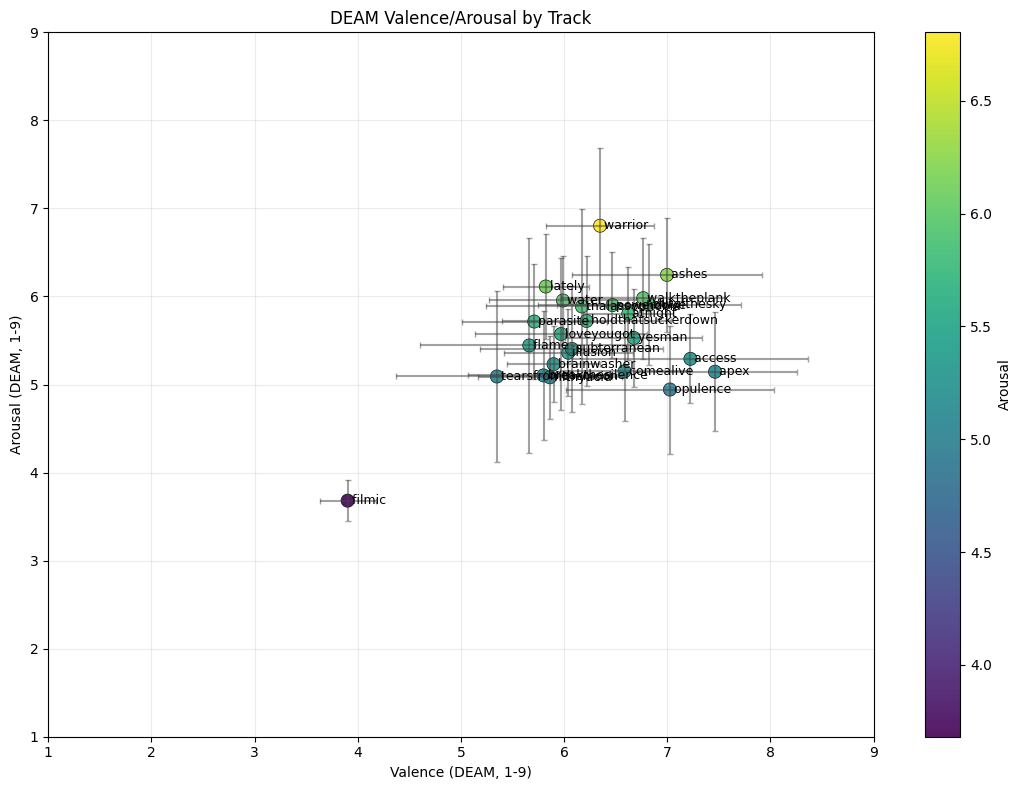

Saved DEAM plot: /Users/josephdaher/Git Repositories/djprojectexploration/data/deam_valence_arousal/deam_valence_arousal_scatter.png


In [11]:
if not deam_rows:
    raise ValueError("No DEAM predictions found. Run the previous cell first.")

names = [Path(row["filename"]).stem for row in deam_rows]
valence = np.array([row["valence"] for row in deam_rows], dtype=np.float32)
arousal = np.array([row["arousal"] for row in deam_rows], dtype=np.float32)
valence_std = np.array([row["valence_std"] for row in deam_rows], dtype=np.float32)
arousal_std = np.array([row["arousal_std"] for row in deam_rows], dtype=np.float32)

fig, ax = plt.subplots(figsize=(11, 8))
scatter = ax.scatter(
    valence,
    arousal,
    c=arousal,
    cmap="viridis",
    s=90,
    alpha=0.9,
    edgecolor="black",
    linewidth=0.5,
)
ax.errorbar(
    valence,
    arousal,
    xerr=valence_std,
    yerr=arousal_std,
    fmt="none",
    ecolor="#444444",
    alpha=0.5,
    capsize=2,
)

for i, name in enumerate(names):
    ax.text(valence[i], arousal[i], f" {name}", fontsize=9, va="center")

ax.set_xlim(1.0, 9.0)
ax.set_ylim(1.0, 9.0)
ax.set_xlabel("Valence (DEAM, 1-9)")
ax.set_ylabel("Arousal (DEAM, 1-9)")
ax.set_title("DEAM Valence/Arousal by Track")
ax.grid(alpha=0.25)

colorbar = fig.colorbar(scatter, ax=ax)
colorbar.set_label("Arousal")

plot_path = DEAM_DATA_DIR / "deam_valence_arousal_scatter.png"
fig.tight_layout()
fig.savefig(plot_path, dpi=220)
plt.show()

print(f"Saved DEAM plot: {plot_path}")



[   INFO   ] TensorflowPredict: Successfully loaded graph file: `/Users/josephdaher/Git Repositories/djprojectexploration/models/msd-musicnn-1.pb`
[   INFO   ] TensorflowPredict: Successfully loaded graph file: `/Users/josephdaher/Git Repositories/djprojectexploration/models/deam-msd-musicnn-2.pb`


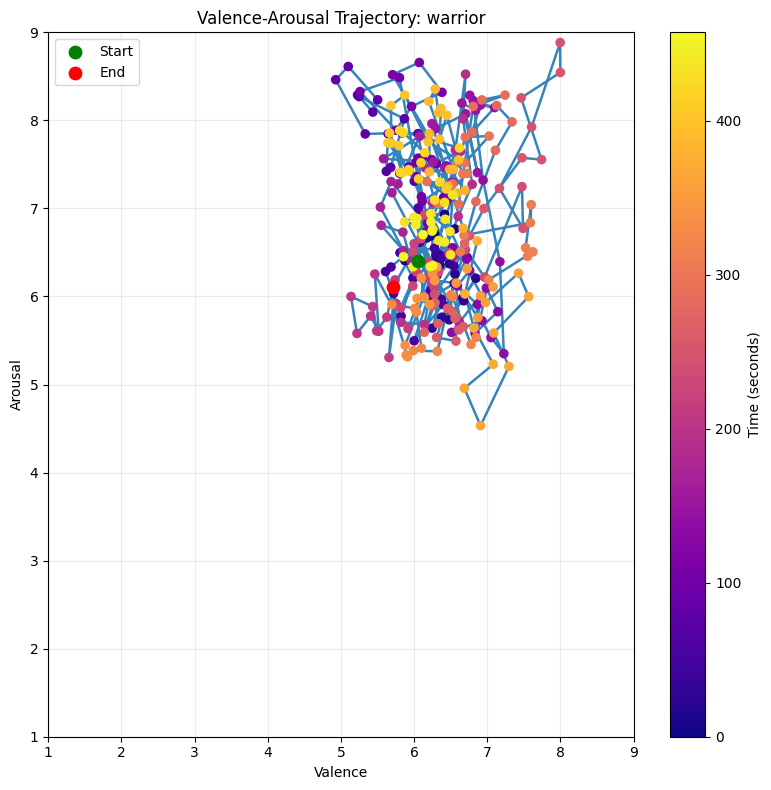

In [16]:
# Valence-Arousal trajectory for one song (2D line over time)

from djprojectexploration.deam_valence_arousal import predict_deam_valence_arousal_musicnn

# Pick a song
audio_file = PROJECT_ROOT / "music" / "aries-mix" / "warrior.mp3"

# Reuse model vars if already defined in earlier cells
musicnn_model = MUSICNN_MODEL_FILE if "MUSICNN_MODEL_FILE" in globals() else (PROJECT_ROOT / "models" / "msd-musicnn-1.pb")
deam_model = DEAM_MODEL_FILE if "DEAM_MODEL_FILE" in globals() else (PROJECT_ROOT / "models" / "deam-msd-musicnn-2.pb")

pred = predict_deam_valence_arousal_musicnn(
    audio_file=audio_file,
    embedding_model_file=musicnn_model,
    regression_model_file=deam_model,
)

points = np.array([[p["valence"], p["arousal"]] for p in pred["segment_predictions"]], dtype=np.float32)
n = len(points)

# Approximate segment times across full song duration
audio = MonoLoader(filename=str(audio_file), sampleRate=16000, resampleQuality=4)()
duration_sec = len(audio) / 16000.0
t = np.linspace(0.0, duration_sec, n, endpoint=False)

fig, ax = plt.subplots(figsize=(8, 8))

# Line path through valence-arousal space (ordered by time)
ax.plot(points[:, 0], points[:, 1], color="#1f77b4", linewidth=1.8, alpha=0.9)

# Color points by time
sc = ax.scatter(points[:, 0], points[:, 1], c=t, cmap="plasma", s=35, zorder=3)

# Mark start/end
ax.scatter(points[0, 0], points[0, 1], color="green", s=80, label="Start", zorder=4)
ax.scatter(points[-1, 0], points[-1, 1], color="red", s=80, label="End", zorder=4)

ax.set_xlim(1, 9)
ax.set_ylim(1, 9)
ax.set_xlabel("Valence")
ax.set_ylabel("Arousal")
ax.set_title(f"Valence-Arousal Trajectory: {audio_file.stem}")
ax.grid(alpha=0.25)
ax.legend(loc="best")

cbar = fig.colorbar(sc, ax=ax)
cbar.set_label("Time (seconds)")

plt.tight_layout()
plt.show()



## MAEST Mix-Order Distance Diagnostics

Compare neighboring tracks in mix order using cosine and Euclidean distance,
and inspect full pairwise distance heatmaps.



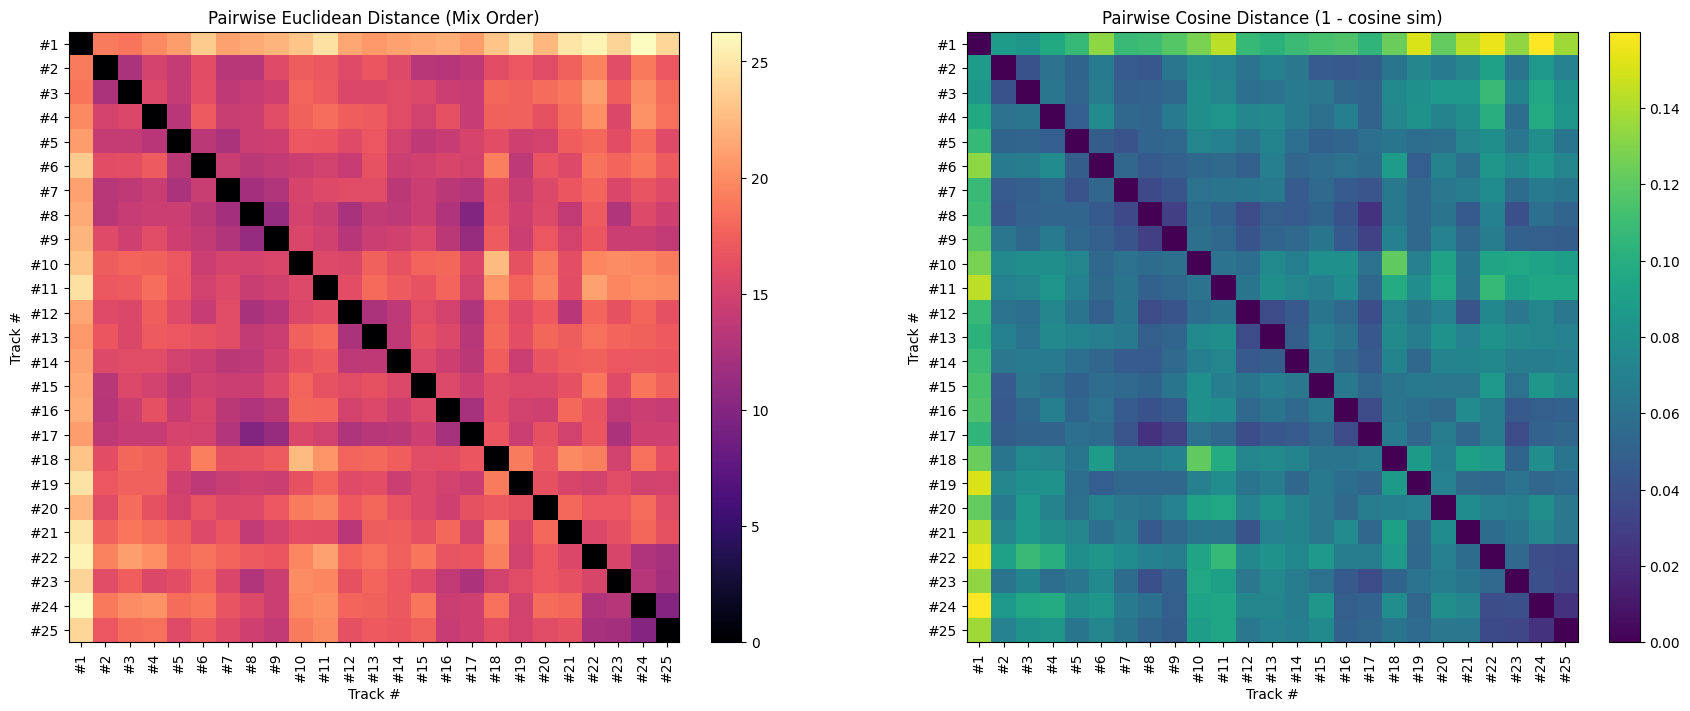

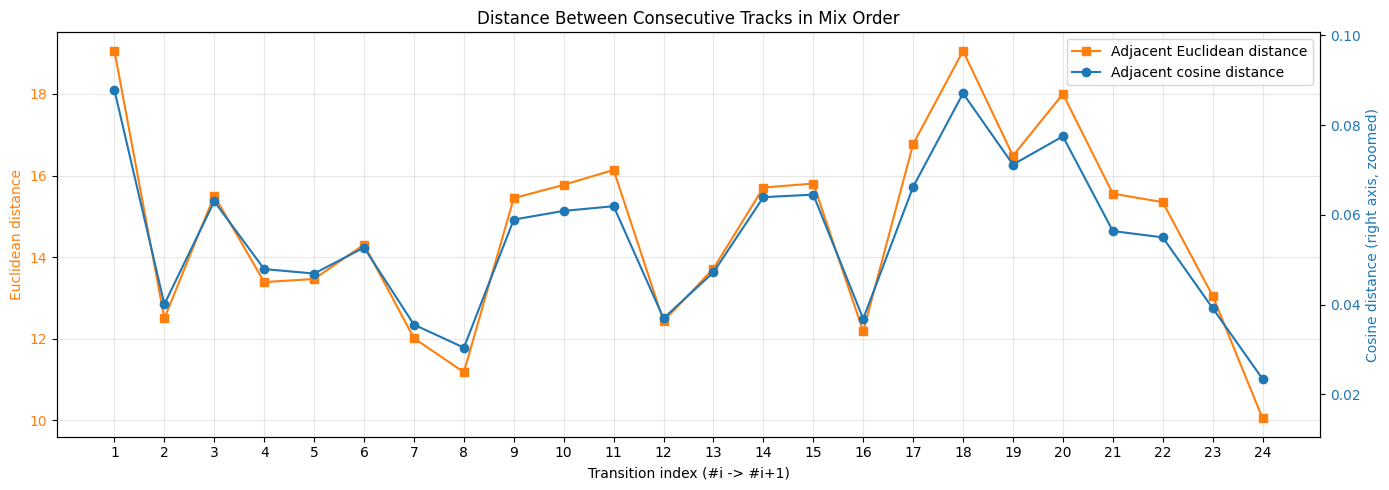

Matched tracks in mix order: 25
Saved transition table: /Users/josephdaher/Git Repositories/djprojectexploration/data/maest_embeddings/mix_similarity/mix_order_transition_distances.csv
Saved pairwise matrices: /Users/josephdaher/Git Repositories/djprojectexploration/data/maest_embeddings/mix_similarity/pairwise_distance_matrices.npz
Saved heatmaps: /Users/josephdaher/Git Repositories/djprojectexploration/data/maest_embeddings/mix_similarity/pairwise_distance_heatmaps.png
Saved adjacent-distance plot: /Users/josephdaher/Git Repositories/djprojectexploration/data/maest_embeddings/mix_similarity/adjacent_transition_distances.png

First 5 transitions:
#1 -> #2: cos_dist=0.0878, euclid=19.0570
#2 -> #3: cos_dist=0.0401, euclid=12.5021
#3 -> #4: cos_dist=0.0630, euclid=15.5044
#4 -> #5: cos_dist=0.0479, euclid=13.3900
#5 -> #6: cos_dist=0.0469, euclid=13.4650


In [ ]:
if "embeddings" not in globals() or "filenames" not in globals():
    raise RuntimeError("Run the MAEST embedding cells first so `embeddings` and `filenames` exist.")

tracklist_csv = PROJECT_ROOT / "music" / "aries-mix" / "aries_mix_tracks.csv"
if not tracklist_csv.exists():
    raise FileNotFoundError(f"Tracklist CSV not found: {tracklist_csv}")

filename_to_idx = {name.lower(): i for i, name in enumerate(filenames)}
ordered_tracks = []

with tracklist_csv.open("r", encoding="utf-8", newline="") as f:
    reader = csv.DictReader(f)
    for row in reader:
        track_num_raw = (row.get("track_number") or row.get("#") or "").strip()
        mp3_name = (row.get("mp3_name") or "").strip().lower()
        title = (row.get("title") or "").strip()
        if not track_num_raw or not mp3_name:
            continue
        try:
            track_number = int(track_num_raw)
        except ValueError:
            continue
        idx = filename_to_idx.get(mp3_name)
        if idx is None:
            continue
        ordered_tracks.append(
            {
                "track_number": track_number,
                "title": title,
                "mp3_name": mp3_name,
                "embedding_index": idx,
            }
        )

ordered_tracks.sort(key=lambda x: x["track_number"])
if len(ordered_tracks) < 2:
    raise ValueError("Need at least 2 matched tracks in CSV to compute mix-order distances.")

order_idx = [t["embedding_index"] for t in ordered_tracks]
ordered_embeddings = embeddings[order_idx].astype(np.float32)
n_tracks = ordered_embeddings.shape[0]

# Pairwise cosine similarity/distance
norms = np.linalg.norm(ordered_embeddings, axis=1, keepdims=True)
norms = np.where(norms == 0, 1.0, norms)
emb_norm = ordered_embeddings / norms
cosine_similarity_matrix = emb_norm @ emb_norm.T
cosine_similarity_matrix = np.clip(cosine_similarity_matrix, -1.0, 1.0)
cosine_distance_matrix = 1.0 - cosine_similarity_matrix
cosine_distance_matrix = np.clip(cosine_distance_matrix, 0.0, 2.0)

# Pairwise Euclidean distance
diff = ordered_embeddings[:, None, :] - ordered_embeddings[None, :, :]
euclidean_distance_matrix = np.linalg.norm(diff, axis=2)

# Consecutive transitions in mix order
transitions = []
for i in range(n_tracks - 1):
    a = ordered_tracks[i]
    b = ordered_tracks[i + 1]
    transitions.append(
        {
            "from_track_number": a["track_number"],
            "from_title": a["title"],
            "from_mp3": a["mp3_name"],
            "to_track_number": b["track_number"],
            "to_title": b["title"],
            "to_mp3": b["mp3_name"],
            "cosine_similarity": float(cosine_similarity_matrix[i, i + 1]),
            "cosine_distance": float(cosine_distance_matrix[i, i + 1]),
            "euclidean_distance": float(euclidean_distance_matrix[i, i + 1]),
        }
    )

# Save outputs
SIM_DIR = DATA_DIR / "mix_similarity"
SIM_DIR.mkdir(parents=True, exist_ok=True)

transitions_csv = SIM_DIR / "mix_order_transition_distances.csv"
with transitions_csv.open("w", newline="", encoding="utf-8") as f:
    writer = csv.DictWriter(
        f,
        fieldnames=[
            "from_track_number",
            "from_title",
            "from_mp3",
            "to_track_number",
            "to_title",
            "to_mp3",
            "cosine_similarity",
            "cosine_distance",
            "euclidean_distance",
        ],
    )
    writer.writeheader()
    writer.writerows(transitions)

labels = [f"#{t['track_number']}" for t in ordered_tracks]
np.savez_compressed(
    SIM_DIR / "pairwise_distance_matrices.npz",
    labels=np.array(labels),
    cosine_similarity=cosine_similarity_matrix,
    cosine_distance=cosine_distance_matrix,
    euclidean_distance=euclidean_distance_matrix,
)

# Heatmaps
fig, axes = plt.subplots(1, 2, figsize=(18, 7), constrained_layout=True)

im0 = axes[0].imshow(euclidean_distance_matrix, cmap="magma")
axes[0].set_title("Pairwise Euclidean Distance (Mix Order)")
axes[0].set_xticks(np.arange(n_tracks))
axes[0].set_yticks(np.arange(n_tracks))
axes[0].set_xticklabels(labels, rotation=90)
axes[0].set_yticklabels(labels)
axes[0].set_xlabel("Track #")
axes[0].set_ylabel("Track #")
fig.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

im1 = axes[1].imshow(cosine_distance_matrix, cmap="viridis")
axes[1].set_title("Pairwise Cosine Distance (1 - cosine sim)")
axes[1].set_xticks(np.arange(n_tracks))
axes[1].set_yticks(np.arange(n_tracks))
axes[1].set_xticklabels(labels, rotation=90)
axes[1].set_yticklabels(labels)
axes[1].set_xlabel("Track #")
axes[1].set_ylabel("Track #")
fig.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

heatmap_path = SIM_DIR / "pairwise_distance_heatmaps.png"
fig.savefig(heatmap_path, dpi=220)
plt.show()

# Adjacent transition trend plot
x = np.arange(1, n_tracks)
adj_cos = np.array([row["cosine_distance"] for row in transitions], dtype=np.float32)
adj_euc = np.array([row["euclidean_distance"] for row in transitions], dtype=np.float32)

fig2, ax_euc = plt.subplots(figsize=(14, 5))

# Left axis: Euclidean distance
line_euc = ax_euc.plot(
    x,
    adj_euc,
    marker="s",
    color="#ff7f0e",
    label="Adjacent Euclidean distance",
)
ax_euc.set_xlabel("Transition index (#i -> #i+1)")
ax_euc.set_ylabel("Euclidean distance", color="#ff7f0e")
ax_euc.tick_params(axis="y", labelcolor="#ff7f0e")
ax_euc.set_xticks(x)
ax_euc.grid(alpha=0.3)

# Right axis: Cosine distance (zoomed/scaled to show variation)
ax_cos = ax_euc.twinx()
line_cos = ax_cos.plot(
    x,
    adj_cos,
    marker="o",
    color="#1f77b4",
    label="Adjacent cosine distance",
)
cos_min = float(adj_cos.min())
cos_max = float(adj_cos.max())
cos_span = cos_max - cos_min
if cos_span < 1e-9:
    cos_span = max(abs(cos_max) * 0.1, 1e-3)
cos_pad = 0.2 * cos_span
ax_cos.set_ylim(cos_min - cos_pad, cos_max + cos_pad)
ax_cos.set_ylabel("Cosine distance (right axis, zoomed)", color="#1f77b4")
ax_cos.tick_params(axis="y", labelcolor="#1f77b4")

ax_euc.set_title("Distance Between Consecutive Tracks in Mix Order")

# Combined legend
lines = line_euc + line_cos
labels_legend = [line.get_label() for line in lines]
ax_euc.legend(lines, labels_legend, loc="best")

transition_plot_path = SIM_DIR / "adjacent_transition_distances.png"
fig2.tight_layout()
fig2.savefig(transition_plot_path, dpi=220)
plt.show()

print(f"Matched tracks in mix order: {n_tracks}")
print(f"Saved transition table: {transitions_csv}")
print(f"Saved pairwise matrices: {SIM_DIR / 'pairwise_distance_matrices.npz'}")
print(f"Saved heatmaps: {heatmap_path}")
print(f"Saved adjacent-distance plot: {transition_plot_path}")
print()
print("First 5 transitions:")
for row in transitions[:5]:
    print(
        f"#{row['from_track_number']} -> #{row['to_track_number']}: "
        f"cos_dist={row['cosine_distance']:.4f}, "
        f"euclid={row['euclidean_distance']:.4f}"
    )



## DEAM Mix-Order Path (Zoomed)

Plot the DJ set path directly in valence/arousal space,
with local-axis zoom so small transitions are easier to see.



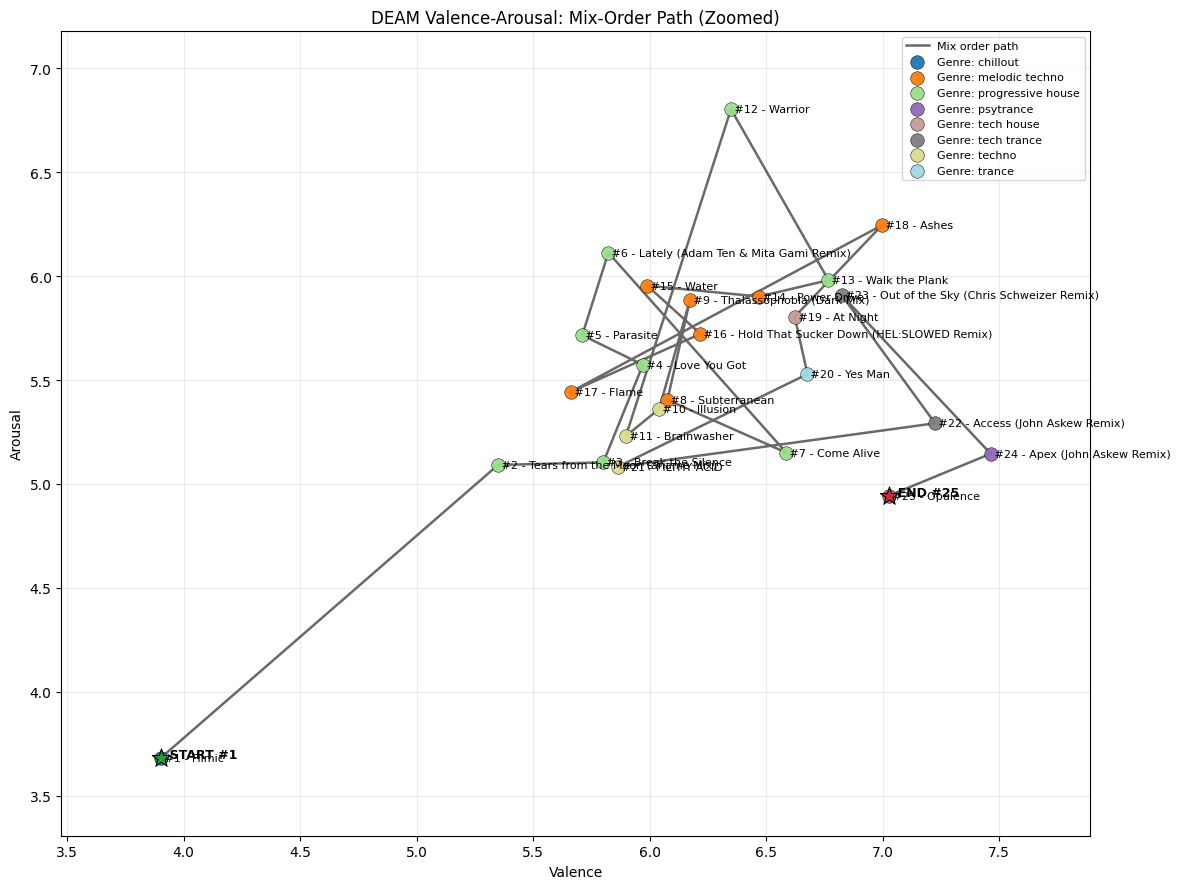

Matched tracks plotted: 25
Genres used for coloring: chillout, melodic techno, progressive house, psytrance, tech house, tech trance, techno, trance
Saved plot: /Users/josephdaher/Git Repositories/djprojectexploration/data/deam_valence_arousal/deam_valence_arousal_mix_order_zoomed.png


In [ ]:
tracklist_csv = PROJECT_ROOT / "music" / "aries-mix" / "aries_mix_tracks.csv"
if not tracklist_csv.exists():
    raise FileNotFoundError(f"Tracklist CSV not found: {tracklist_csv}")

DEAM_DATA_DIR = PROJECT_ROOT / "data" / "deam_valence_arousal"
summary_json_path = DEAM_DATA_DIR / "deam_track_predictions.json"

# Build lookup: filename -> (valence, arousal)
val_ar_lookup = {}

if "deam_rows" in globals() and deam_rows:
    for row in deam_rows:
        name = (row.get("filename") or "").strip().lower()
        if not name:
            continue
        val_ar_lookup[name] = {
            "valence": float(row["valence"]),
            "arousal": float(row["arousal"]),
        }
elif summary_json_path.exists():
    payload = json.loads(summary_json_path.read_text(encoding="utf-8"))
    for row in payload.get("tracks", []):
        name = (row.get("filename") or "").strip().lower()
        if not name:
            continue
        val_ar_lookup[name] = {
            "valence": float(row["valence"]),
            "arousal": float(row["arousal"]),
        }
else:
    raise RuntimeError(
        "No DEAM predictions found. Run the DEAM prediction cell first (or ensure deam_track_predictions.json exists)."
    )

ordered_points = []
with tracklist_csv.open("r", encoding="utf-8", newline="") as f:
    reader = csv.DictReader(f)
    for row in reader:
        track_num_raw = (row.get("track_number") or row.get("#") or "").strip()
        mp3_name = (row.get("mp3_name") or "").strip().lower()
        title = (row.get("title") or "").strip()
        genre = (row.get("genre") or "").strip() or "Unknown"
        if not track_num_raw or not mp3_name:
            continue
        try:
            track_num = int(track_num_raw)
        except ValueError:
            continue

        pred = val_ar_lookup.get(mp3_name)
        if pred is None:
            continue

        ordered_points.append(
            {
                "track_num": track_num,
                "title": title if title else Path(mp3_name).stem,
                "mp3_name": mp3_name,
                "genre": genre,
                "valence": float(pred["valence"]),
                "arousal": float(pred["arousal"]),
            }
        )

ordered_points.sort(key=lambda x: x["track_num"])
if len(ordered_points) < 2:
    raise ValueError("Need at least 2 matched tracks with DEAM predictions to plot mix-order path.")

valence = np.array([p["valence"] for p in ordered_points], dtype=np.float32)
arousal = np.array([p["arousal"] for p in ordered_points], dtype=np.float32)

fig, ax = plt.subplots(figsize=(12, 9))

# Mix-order line
ax.plot(
    valence,
    arousal,
    color="#444444",
    linewidth=1.8,
    alpha=0.8,
    label="Mix order path",
    zorder=2,
)

# Genre colors
genres = sorted({p["genre"] for p in ordered_points}, key=lambda g: g.lower())
cmap = plt.get_cmap("tab20", max(1, len(genres)))
genre_to_color = {g: cmap(i) for i, g in enumerate(genres)}

for genre in genres:
    pts = [p for p in ordered_points if p["genre"] == genre]
    x = [p["valence"] for p in pts]
    y = [p["arousal"] for p in pts]
    ax.scatter(
        x,
        y,
        s=95,
        color=genre_to_color[genre],
        edgecolor="black",
        linewidth=0.35,
        alpha=0.95,
        label=f"Genre: {genre}",
        zorder=3,
    )

# Labels: #<track> - <song>
for p in ordered_points:
    ax.text(
        p["valence"],
        p["arousal"],
        f" #{p['track_num']} - {p['title']}",
        fontsize=8,
        va="center",
    )

# Start/end markers
first = ordered_points[0]
last = ordered_points[-1]
ax.scatter(first["valence"], first["arousal"], s=190, marker="*", color="#2ca02c", edgecolor="black", linewidth=0.8, zorder=5)
ax.scatter(last["valence"], last["arousal"], s=190, marker="*", color="#d62728", edgecolor="black", linewidth=0.8, zorder=5)
ax.text(first["valence"], first["arousal"], f"  START #{first['track_num']}", fontsize=9, weight="bold")
ax.text(last["valence"], last["arousal"], f"  END #{last['track_num']}", fontsize=9, weight="bold")

# Zoom to local min/max with padding (instead of fixed [1,9])
v_min, v_max = float(valence.min()), float(valence.max())
a_min, a_max = float(arousal.min()), float(arousal.max())
v_span = max(v_max - v_min, 1e-3)
a_span = max(a_max - a_min, 1e-3)
v_pad = 0.12 * v_span
a_pad = 0.12 * a_span
ax.set_xlim(v_min - v_pad, v_max + v_pad)
ax.set_ylim(a_min - a_pad, a_max + a_pad)

ax.set_title("DEAM Valence-Arousal: Mix-Order Path (Zoomed)")
ax.set_xlabel("Valence")
ax.set_ylabel("Arousal")
ax.grid(alpha=0.25)
ax.legend(loc="best", fontsize=8)

plot_path_va_mix = DEAM_DATA_DIR / "deam_valence_arousal_mix_order_zoomed.png"
fig.tight_layout()
fig.savefig(plot_path_va_mix, dpi=220)
plt.show()

print(f"Matched tracks plotted: {len(ordered_points)}")
print(f"Genres used for coloring: {', '.join(genres)}")
print(f"Saved plot: {plot_path_va_mix}")



## Chroma Embeddings: Mix Path + Similarity Matrix

Generate chroma embeddings for the mix,
then visualize trajectory + pairwise similarity in one place.



In [ ]:
CHROMA_DATA_DIR = PROJECT_ROOT / "data" / "chroma_embeddings"
CHROMA_DATA_DIR.mkdir(parents=True, exist_ok=True)

chroma_records = []

for audio_file in mp3_files:
    payload = generate_chroma_embedding(audio_file=audio_file)
    out_json = CHROMA_DATA_DIR / f"{audio_file.stem}_chroma_embedding.json"
    with out_json.open("w", encoding="utf-8") as f:
        json.dump(payload, f, indent=4)

    chroma_records.append(
        {
            "filename": audio_file.name,
            "embedding": np.asarray(payload["embedding"], dtype=np.float32),
            "embedding_dimension": int(payload["embedding_dimension"]),
            "embedding_type": str(payload.get("embedding_type", "unknown")),
            "per_track_file": to_project_relpath(out_json),
        }
    )

    print(f"Saved output: {out_json.name} (dim={payload['embedding_dimension']})")

if not chroma_records:
    raise RuntimeError("No chroma embeddings were generated.")

chroma_filenames = [r["filename"] for r in chroma_records]
chroma_embeddings = np.vstack([r["embedding"] for r in chroma_records]).astype(np.float32)

npz_path = CHROMA_DATA_DIR / "chroma_embeddings.npz"
np.savez_compressed(
    npz_path,
    filenames=np.array(chroma_filenames),
    embeddings=chroma_embeddings,
)

manifest = {
    "title": "Chroma Embedding Collection",
    "embedding_type": str(chroma_records[0].get("embedding_type", "unknown")),
    "num_tracks": len(chroma_records),
    "embedding_dimension": int(chroma_embeddings.shape[1]),
    "tracks": [
        {
            "filename": r["filename"],
            "embedding_dimension": r["embedding_dimension"],
            "per_track_embedding_file": r["per_track_file"],
        }
        for r in chroma_records
    ],
}

manifest_path = CHROMA_DATA_DIR / "chroma_embeddings_manifest.json"
with manifest_path.open("w", encoding="utf-8") as f:
    json.dump(manifest, f, indent=4)

print(f"\nSaved chroma matrix: {to_project_relpath(npz_path)}")
print(f"Saved output: chroma manifest: {to_project_relpath(manifest_path)}")
print(f"Chroma embedding matrix shape: {chroma_embeddings.shape}")





Saved access_chroma_embedding.json (dim=38)
Saved apex_chroma_embedding.json (dim=38)
Saved ashes_chroma_embedding.json (dim=38)
Saved atnight_chroma_embedding.json (dim=38)
Saved brainwasher_chroma_embedding.json (dim=38)
Saved breakthesilence_chroma_embedding.json (dim=38)
Saved comealive_chroma_embedding.json (dim=38)
Saved filmic_chroma_embedding.json (dim=38)
Saved filthyacid_chroma_embedding.json (dim=38)
Saved flame_chroma_embedding.json (dim=38)
Saved holdthatsuckerdown_chroma_embedding.json (dim=38)
Saved illusion_chroma_embedding.json (dim=38)
Saved lately_chroma_embedding.json (dim=38)
Saved loveyougot_chroma_embedding.json (dim=38)
Saved opulence_chroma_embedding.json (dim=38)
Saved outofthesky_chroma_embedding.json (dim=38)
Saved parasite_chroma_embedding.json (dim=38)
Saved powerdrive_chroma_embedding.json (dim=38)
Saved subterranean_chroma_embedding.json (dim=38)
Saved tearsfromthemoon_chroma_embedding.json (dim=38)
Saved thalassophobia_chroma_embedding.json (dim=38)
Sav

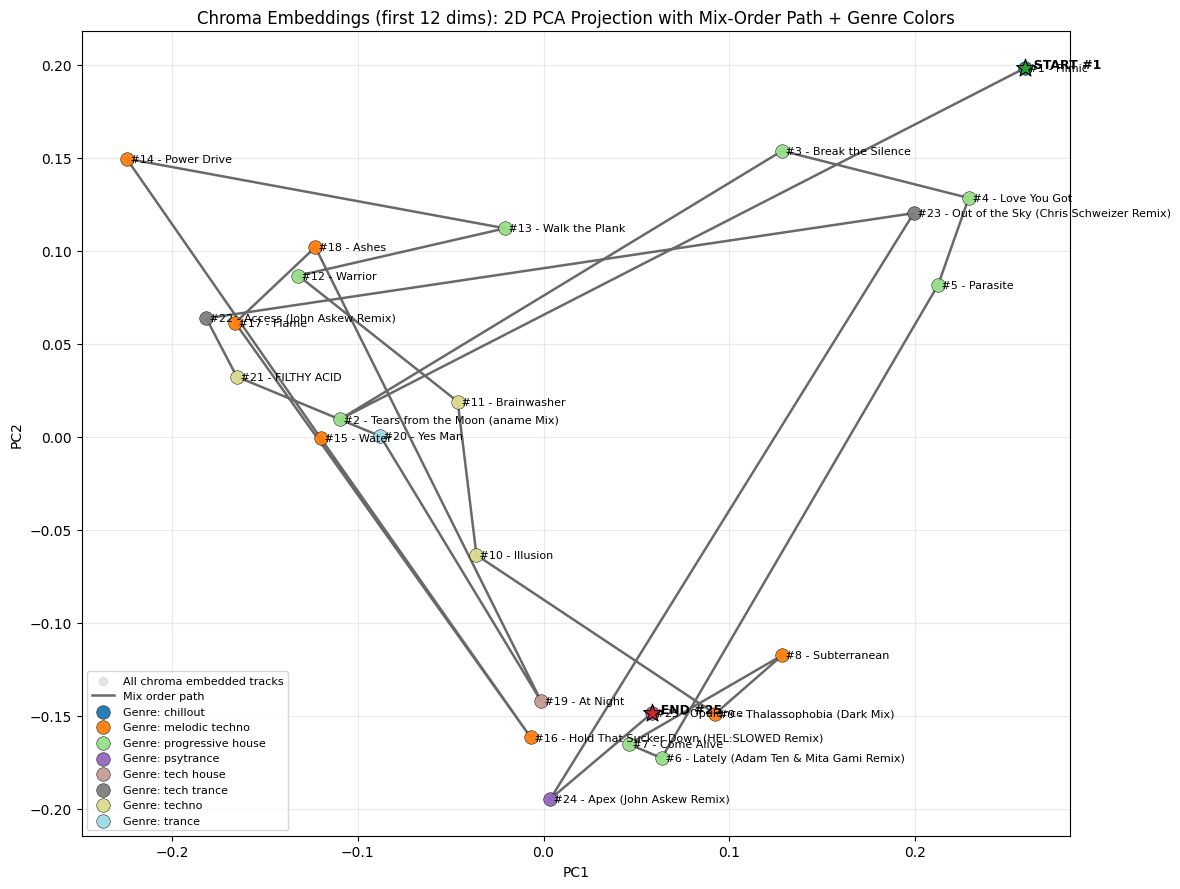

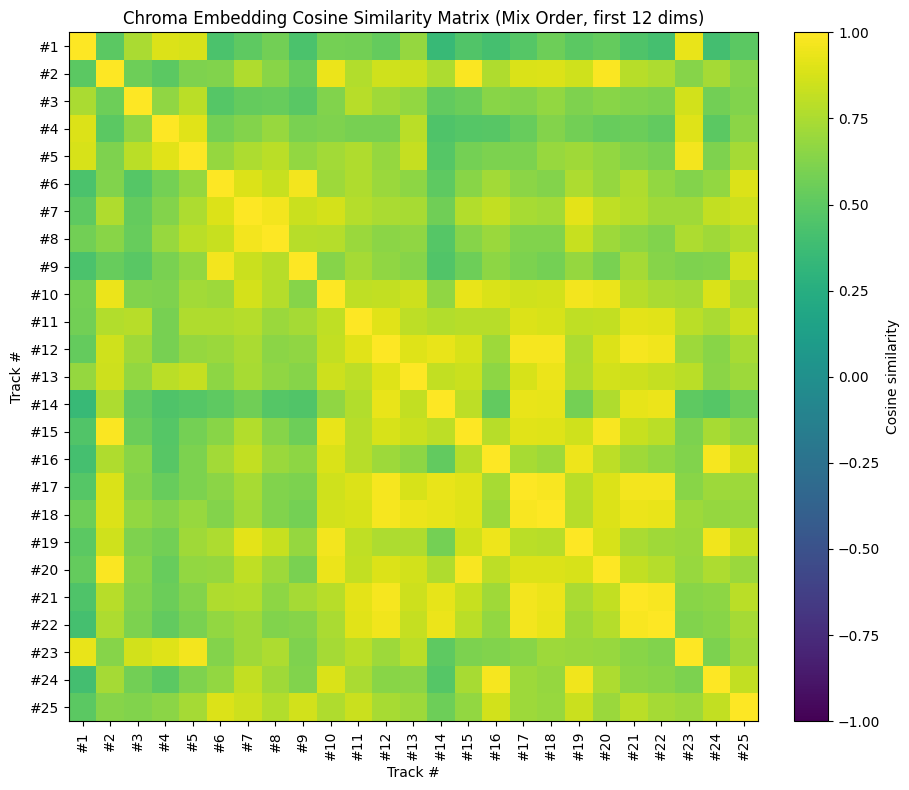

Saved chroma mix-order plot: data/chroma_embeddings/chroma_embeddings_pca_mix_plot.png
Saved chroma similarity matrix plot: data/chroma_embeddings/chroma_cosine_similarity_matrix.png
Saved chroma similarity matrix data: data/chroma_embeddings/chroma_cosine_similarity_matrix.npz
Genres used for coloring: chillout, melodic techno, progressive house, psytrance, tech house, tech trance, techno, trance
Used first 12 embedding dimensions for PCA/similarity.


In [ ]:
if chroma_embeddings.shape[0] < 2:
    raise ValueError("Need at least 2 tracks to build chroma projection/similarity visuals.")

CHROMA_DIMS_TO_USE = 12
if chroma_embeddings.shape[1] < CHROMA_DIMS_TO_USE:
    raise ValueError(
        f"Requested first {CHROMA_DIMS_TO_USE} dimensions, but only {chroma_embeddings.shape[1]} are available."
    )

chroma_embeddings_subset = chroma_embeddings[:, :CHROMA_DIMS_TO_USE]

# 2D PCA projection for chroma embeddings
centered = chroma_embeddings_subset - chroma_embeddings_subset.mean(axis=0, keepdims=True)
_u, _s, vt = np.linalg.svd(centered, full_matrices=False)
chroma_coords = centered @ vt[:2].T
if chroma_coords.shape[1] < 2:
    chroma_coords = np.pad(chroma_coords, ((0, 0), (0, 2 - chroma_coords.shape[1])), mode="constant")

tracklist_csv = PROJECT_ROOT / "music" / "aries-mix" / "aries_mix_tracks.csv"
if not tracklist_csv.exists():
    raise FileNotFoundError(f"Tracklist CSV not found: {tracklist_csv}")

filename_to_idx = {name.lower(): i for i, name in enumerate(chroma_filenames)}
ordered_matches = []

with tracklist_csv.open("r", encoding="utf-8", newline="") as f:
    reader = csv.DictReader(f)
    for row in reader:
        track_num_raw = (row.get("track_number") or row.get("#") or "").strip()
        mp3_name = (row.get("mp3_name") or "").strip().lower()
        title = (row.get("title") or "").strip()
        genre = (row.get("genre") or "").strip() or "Unknown"

        if not track_num_raw or not mp3_name:
            continue
        try:
            track_num = int(track_num_raw)
        except ValueError:
            continue

        idx = filename_to_idx.get(mp3_name)
        if idx is None:
            continue

        ordered_matches.append(
            {
                "track_num": track_num,
                "idx": idx,
                "mp3_name": mp3_name,
                "title": title if title else Path(mp3_name).stem,
                "genre": genre,
            }
        )

ordered_matches.sort(key=lambda x: x["track_num"])
if len(ordered_matches) < 2:
    raise ValueError("Need at least 2 matched tracks for chroma mix-order plot.")

# Plot mix-order path with genre coloring and labels
fig, ax = plt.subplots(figsize=(12, 9))

ax.scatter(
    chroma_coords[:, 0],
    chroma_coords[:, 1],
    s=35,
    color="#c7c7c7",
    alpha=0.45,
    label="All chroma embedded tracks",
)

order_idx = [item["idx"] for item in ordered_matches]
path_coords = chroma_coords[order_idx]

ax.plot(
    path_coords[:, 0],
    path_coords[:, 1],
    color="#444444",
    linewidth=1.8,
    alpha=0.8,
    label="Mix order path",
    zorder=2,
)

genres = sorted({item["genre"] for item in ordered_matches}, key=lambda g: g.lower())
cmap = plt.get_cmap("tab20", max(1, len(genres)))
genre_to_color = {genre: cmap(i) for i, genre in enumerate(genres)}

for genre in genres:
    pts = [item for item in ordered_matches if item["genre"] == genre]
    idxs = [item["idx"] for item in pts]
    gcoords = chroma_coords[idxs]
    ax.scatter(
        gcoords[:, 0],
        gcoords[:, 1],
        s=95,
        color=genre_to_color[genre],
        edgecolor="black",
        linewidth=0.35,
        alpha=0.95,
        label=f"Genre: {genre}",
        zorder=3,
    )

for item in ordered_matches:
    ax.text(
        chroma_coords[item["idx"], 0],
        chroma_coords[item["idx"], 1],
        f" #{item['track_num']} - {item['title']}",
        fontsize=8,
        va="center",
    )

first = ordered_matches[0]
last = ordered_matches[-1]
ax.scatter(chroma_coords[first["idx"], 0], chroma_coords[first["idx"], 1], s=180, marker="*", color="#2ca02c", edgecolor="black", linewidth=0.8, zorder=5)
ax.scatter(chroma_coords[last["idx"], 0], chroma_coords[last["idx"], 1], s=180, marker="*", color="#d62728", edgecolor="black", linewidth=0.8, zorder=5)
ax.text(chroma_coords[first["idx"], 0], chroma_coords[first["idx"], 1], f"  START #{first['track_num']}", fontsize=9, weight="bold")
ax.text(chroma_coords[last["idx"], 0], chroma_coords[last["idx"], 1], f"  END #{last['track_num']}", fontsize=9, weight="bold")

ax.set_title(f"Chroma Embeddings (first {CHROMA_DIMS_TO_USE} dims): 2D PCA Projection with Mix-Order Path + Genre Colors")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.grid(alpha=0.25)
ax.legend(loc="best", fontsize=8)

plot_path = CHROMA_DATA_DIR / "chroma_embeddings_pca_mix_plot.png"
fig.tight_layout()
fig.savefig(plot_path, dpi=220)
plt.show()

# Similarity matrix (cosine similarity) in mix order
ordered_emb = chroma_embeddings_subset[order_idx].astype(np.float32)
norms = np.linalg.norm(ordered_emb, axis=1, keepdims=True)
norms = np.where(norms == 0, 1.0, norms)
ordered_norm = ordered_emb / norms
cosine_similarity = ordered_norm @ ordered_norm.T
cosine_similarity = np.clip(cosine_similarity, -1.0, 1.0)

matrix_labels = [f"#{item['track_num']}" for item in ordered_matches]

fig2, ax2 = plt.subplots(figsize=(10, 8))
im = ax2.imshow(cosine_similarity, cmap="viridis", vmin=-1.0, vmax=1.0)
ax2.set_title(f"Chroma Embedding Cosine Similarity Matrix (Mix Order, first {CHROMA_DIMS_TO_USE} dims)")
ax2.set_xticks(np.arange(len(matrix_labels)))
ax2.set_yticks(np.arange(len(matrix_labels)))
ax2.set_xticklabels(matrix_labels, rotation=90)
ax2.set_yticklabels(matrix_labels)
ax2.set_xlabel("Track #")
ax2.set_ylabel("Track #")
fig2.colorbar(im, ax=ax2, fraction=0.046, pad=0.04, label="Cosine similarity")
fig2.tight_layout()

matrix_plot_path = CHROMA_DATA_DIR / "chroma_cosine_similarity_matrix.png"
fig2.savefig(matrix_plot_path, dpi=220)
plt.show()

np.savez_compressed(
    CHROMA_DATA_DIR / "chroma_cosine_similarity_matrix.npz",
    labels=np.array(matrix_labels),
    cosine_similarity=cosine_similarity,
)

print(f"Saved output: chroma mix-order plot: {to_project_relpath(plot_path)}")
print(f"Saved output: chroma similarity matrix plot: {to_project_relpath(matrix_plot_path)}")
print(f"Saved output: chroma similarity matrix data: {to_project_relpath(CHROMA_DATA_DIR / 'chroma_cosine_similarity_matrix.npz')}")
print(f"Genres used for coloring: {', '.join(genres)}")
print(f"Used first {CHROMA_DIMS_TO_USE} embedding dimensions for PCA/similarity.")





## Chroma Mean Vectors + Key Comparison

For each track, show the mean pitch-class profile and compare:
- detected key from Essentia
- CSV key tags (Camelot converted to standard notation)



/var/folders/gw/gyqm76mn3d3_vjqrr211cp3m0000gn/T/ipykernel_58253/3061343057.py:187: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


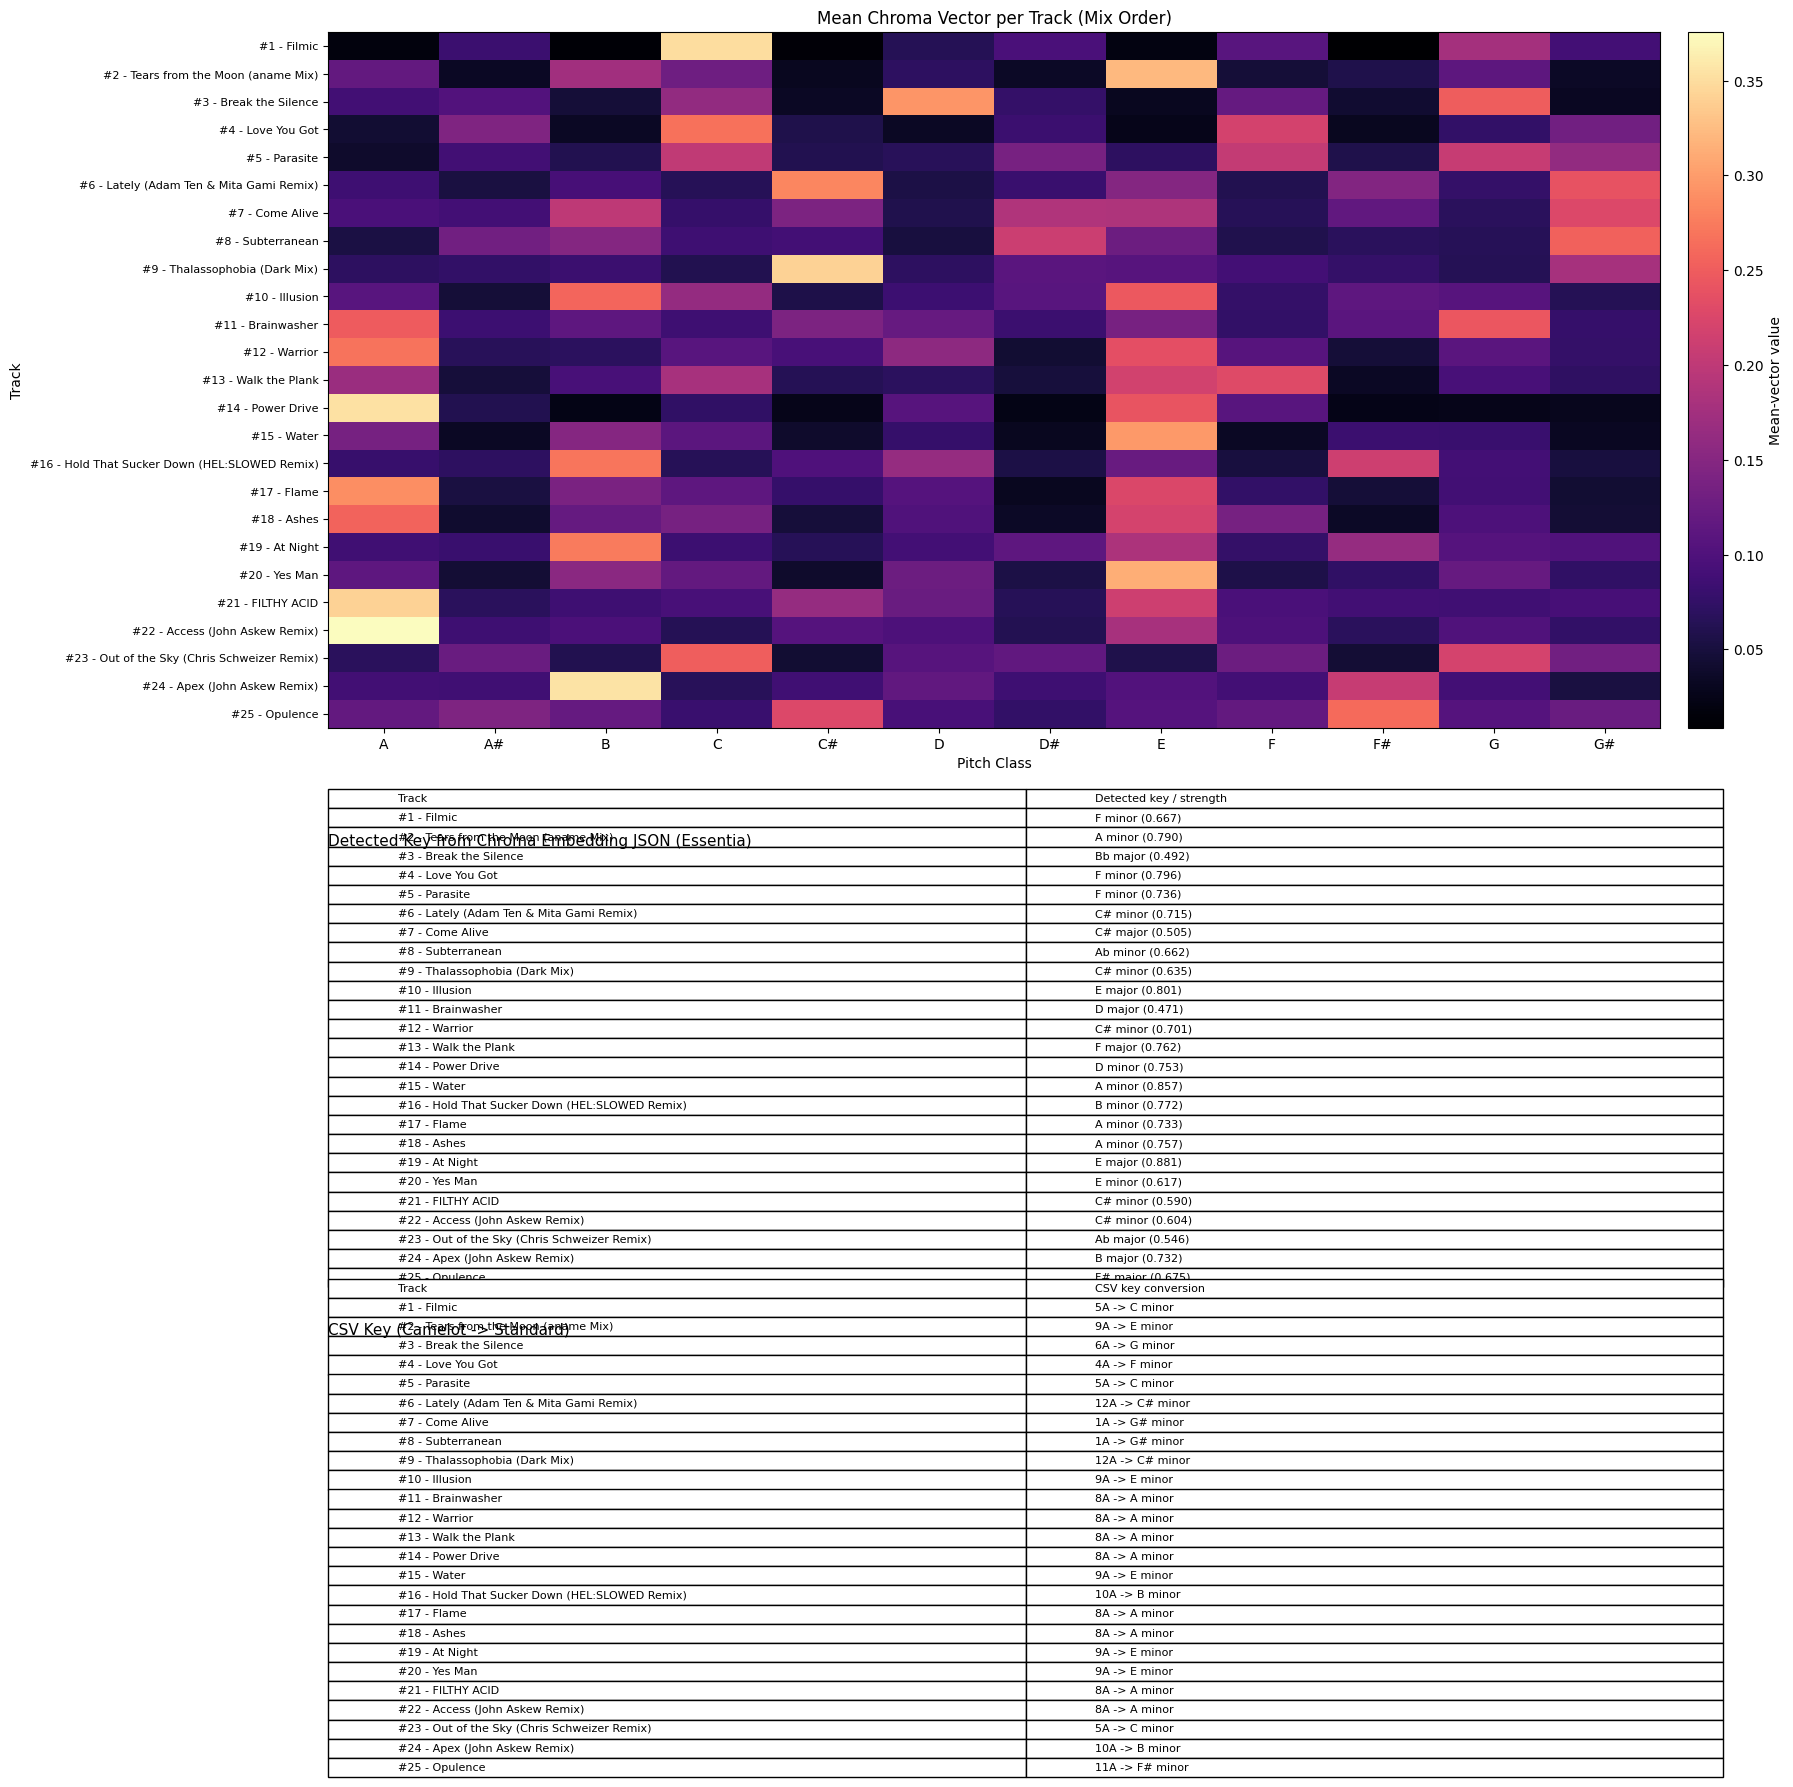

Saved plot: data/chroma_embeddings/chroma_mean_vectors_key_comparison.png
Tracks visualized: 25


In [ ]:
CHROMA_DATA_DIR = PROJECT_ROOT / "data" / "chroma_embeddings"
TRACKLIST_CSV = PROJECT_ROOT / "music" / "aries-mix" / "aries_mix_tracks.csv"

if not TRACKLIST_CSV.exists():
    raise FileNotFoundError(f"Tracklist CSV not found: {TRACKLIST_CSV}")
if not CHROMA_DATA_DIR.exists():
    raise FileNotFoundError(f"Chroma embedding directory not found: {CHROMA_DATA_DIR}")

camelot_to_standard = {
    "1A": "G# minor",
    "2A": "D# minor",
    "3A": "A# minor",
    "4A": "F minor",
    "5A": "C minor",
    "6A": "G minor",
    "7A": "D minor",
    "8A": "A minor",
    "9A": "E minor",
    "10A": "B minor",
    "11A": "F# minor",
    "12A": "C# minor",
    "1B": "B major",
    "2B": "F# major",
    "3B": "C# major",
    "4B": "G# major",
    "5B": "D# major",
    "6B": "A# major",
    "7B": "F major",
    "8B": "C major",
    "9B": "G major",
    "10B": "D major",
    "11B": "A major",
    "12B": "E major",
}


def convert_camelot_key(value: str) -> str:
    if value is None:
        return "N/A"
    token = value.strip().upper()
    m = re.match(r"^(\d{1,2})([AB])$", token)
    if not m:
        return "N/A"
    normalized = f"{int(m.group(1))}{m.group(2)}"
    return camelot_to_standard.get(normalized, "N/A")


with TRACKLIST_CSV.open("r", encoding="utf-8", newline="") as f:
    reader = csv.DictReader(f)
    csv_rows = list(reader)

ordered_rows = []
for row in csv_rows:
    tn = (row.get("track_number") or row.get("#") or "").strip()
    mp3_name = (row.get("mp3_name") or "").strip()
    title = (row.get("title") or "").strip() or Path(mp3_name).stem
    camelot = (row.get("key") or "").strip()
    if not tn or not mp3_name:
        continue
    try:
        track_num = int(tn)
    except ValueError:
        continue
    ordered_rows.append(
        {
            "track_num": track_num,
            "title": title,
            "mp3_name": mp3_name,
            "camelot": camelot,
        }
    )

ordered_rows.sort(key=lambda x: x["track_num"])
if not ordered_rows:
    raise RuntimeError("No usable rows found in tracklist CSV.")

pitch_labels_12 = ["A", "A#", "B", "C", "C#", "D", "D#", "E", "F", "F#", "G", "G#"]

mean_vectors = []
track_labels = []
detected_key_lines = []
csv_key_lines = []
missing_embeddings = []

for row in ordered_rows:
    embedding_file = CHROMA_DATA_DIR / f"{Path(row['mp3_name']).stem}_chroma_embedding.json"
    if not embedding_file.exists():
        missing_embeddings.append(row["mp3_name"])
        continue

    with embedding_file.open("r", encoding="utf-8") as f:
        payload = json.load(f)

    embedding = np.asarray(payload.get("embedding", []), dtype=np.float32)
    chroma_bins = int(payload.get("chroma_bins", 12))
    if embedding.size < chroma_bins or chroma_bins <= 0:
        missing_embeddings.append(row["mp3_name"])
        continue

    mean_vector = embedding[:chroma_bins].astype(np.float32)
    mean_vectors.append(mean_vector)

    label = f"#{row['track_num']} - {row['title']}"
    track_labels.append(label)

    key_est = payload.get("key_estimate", {})
    det_key = str(key_est.get("key", "N/A"))
    det_scale = str(key_est.get("scale", "unknown"))
    det_strength = key_est.get("strength", None)
    if isinstance(det_strength, (int, float)):
        det_txt = f"{det_key} {det_scale} ({float(det_strength):.3f})"
    else:
        det_txt = f"{det_key} {det_scale}"
    detected_key_lines.append([label, det_txt])

    camelot_value = row["camelot"] or "N/A"
    csv_standard = convert_camelot_key(camelot_value)
    csv_key_lines.append([label, f"{camelot_value} -> {csv_standard}"])

if not mean_vectors:
    raise RuntimeError("No chroma embedding JSON files were matched from CSV rows.")

mean_matrix = np.vstack(mean_vectors)
n_tracks, n_bins = mean_matrix.shape

if n_bins == 12:
    x_tick_labels = pitch_labels_12
else:
    x_tick_labels = [f"bin {i}" for i in range(n_bins)]

fig_height = max(14, 0.55 * n_tracks + 8)
fig = plt.figure(figsize=(18, fig_height))
gs = fig.add_gridspec(3, 1, height_ratios=[3.5, 1.8, 1.8], hspace=0.28)

# Top: mean-vector matrix heatmap
ax0 = fig.add_subplot(gs[0])
im = ax0.imshow(mean_matrix, aspect="auto", cmap="magma", interpolation="nearest")
ax0.set_title("Mean Chroma Vector per Track (Mix Order)")
ax0.set_xlabel("Pitch Class")
ax0.set_ylabel("Track")
ax0.set_xticks(np.arange(n_bins))
ax0.set_xticklabels(x_tick_labels, rotation=0)
ax0.set_yticks(np.arange(n_tracks))
ax0.set_yticklabels(track_labels, fontsize=8)
cb = fig.colorbar(im, ax=ax0, fraction=0.025, pad=0.02)
cb.set_label("Mean-vector value")

# Middle: detected key/strength table
ax1 = fig.add_subplot(gs[1])
ax1.axis("off")
ax1.set_title("Detected Key from Chroma Embedding JSON (Essentia)", loc="left", fontsize=11, pad=10)
table1 = ax1.table(
    cellText=detected_key_lines,
    colLabels=["Track", "Detected key / strength"],
    loc="center",
    cellLoc="left",
    colLoc="left",
)
table1.auto_set_font_size(False)
table1.set_fontsize(8)
table1.scale(1.0, 1.15)

# Bottom: CSV Camelot key converted to standard key names
ax2 = fig.add_subplot(gs[2])
ax2.axis("off")
ax2.set_title("CSV Key (Camelot -> Standard)", loc="left", fontsize=11, pad=10)
table2 = ax2.table(
    cellText=csv_key_lines,
    colLabels=["Track", "CSV key conversion"],
    loc="center",
    cellLoc="left",
    colLoc="left",
)
table2.auto_set_font_size(False)
table2.set_fontsize(8)
table2.scale(1.0, 1.15)

output_plot = CHROMA_DATA_DIR / "chroma_mean_vectors_key_comparison.png"
fig.tight_layout()
fig.savefig(output_plot, dpi=220, bbox_inches="tight")
plt.show()

print(f"Saved output: plot: {to_project_relpath(output_plot)}")
print(f"Tracks visualized: {n_tracks}")
if missing_embeddings:
    print(f"Missing/invalid chroma embedding files ({len(missing_embeddings)}):")
    for name in missing_embeddings:
        print(f"  - {name}")





## Circle-of-Fifths Chroma View (Shift-Aware)

Re-express the chroma matrix in circle-of-fifths order,
apply CSV semitone key shifts, and overlay shifted key-root markers.

Key tables are exported separately below the plot workflow.



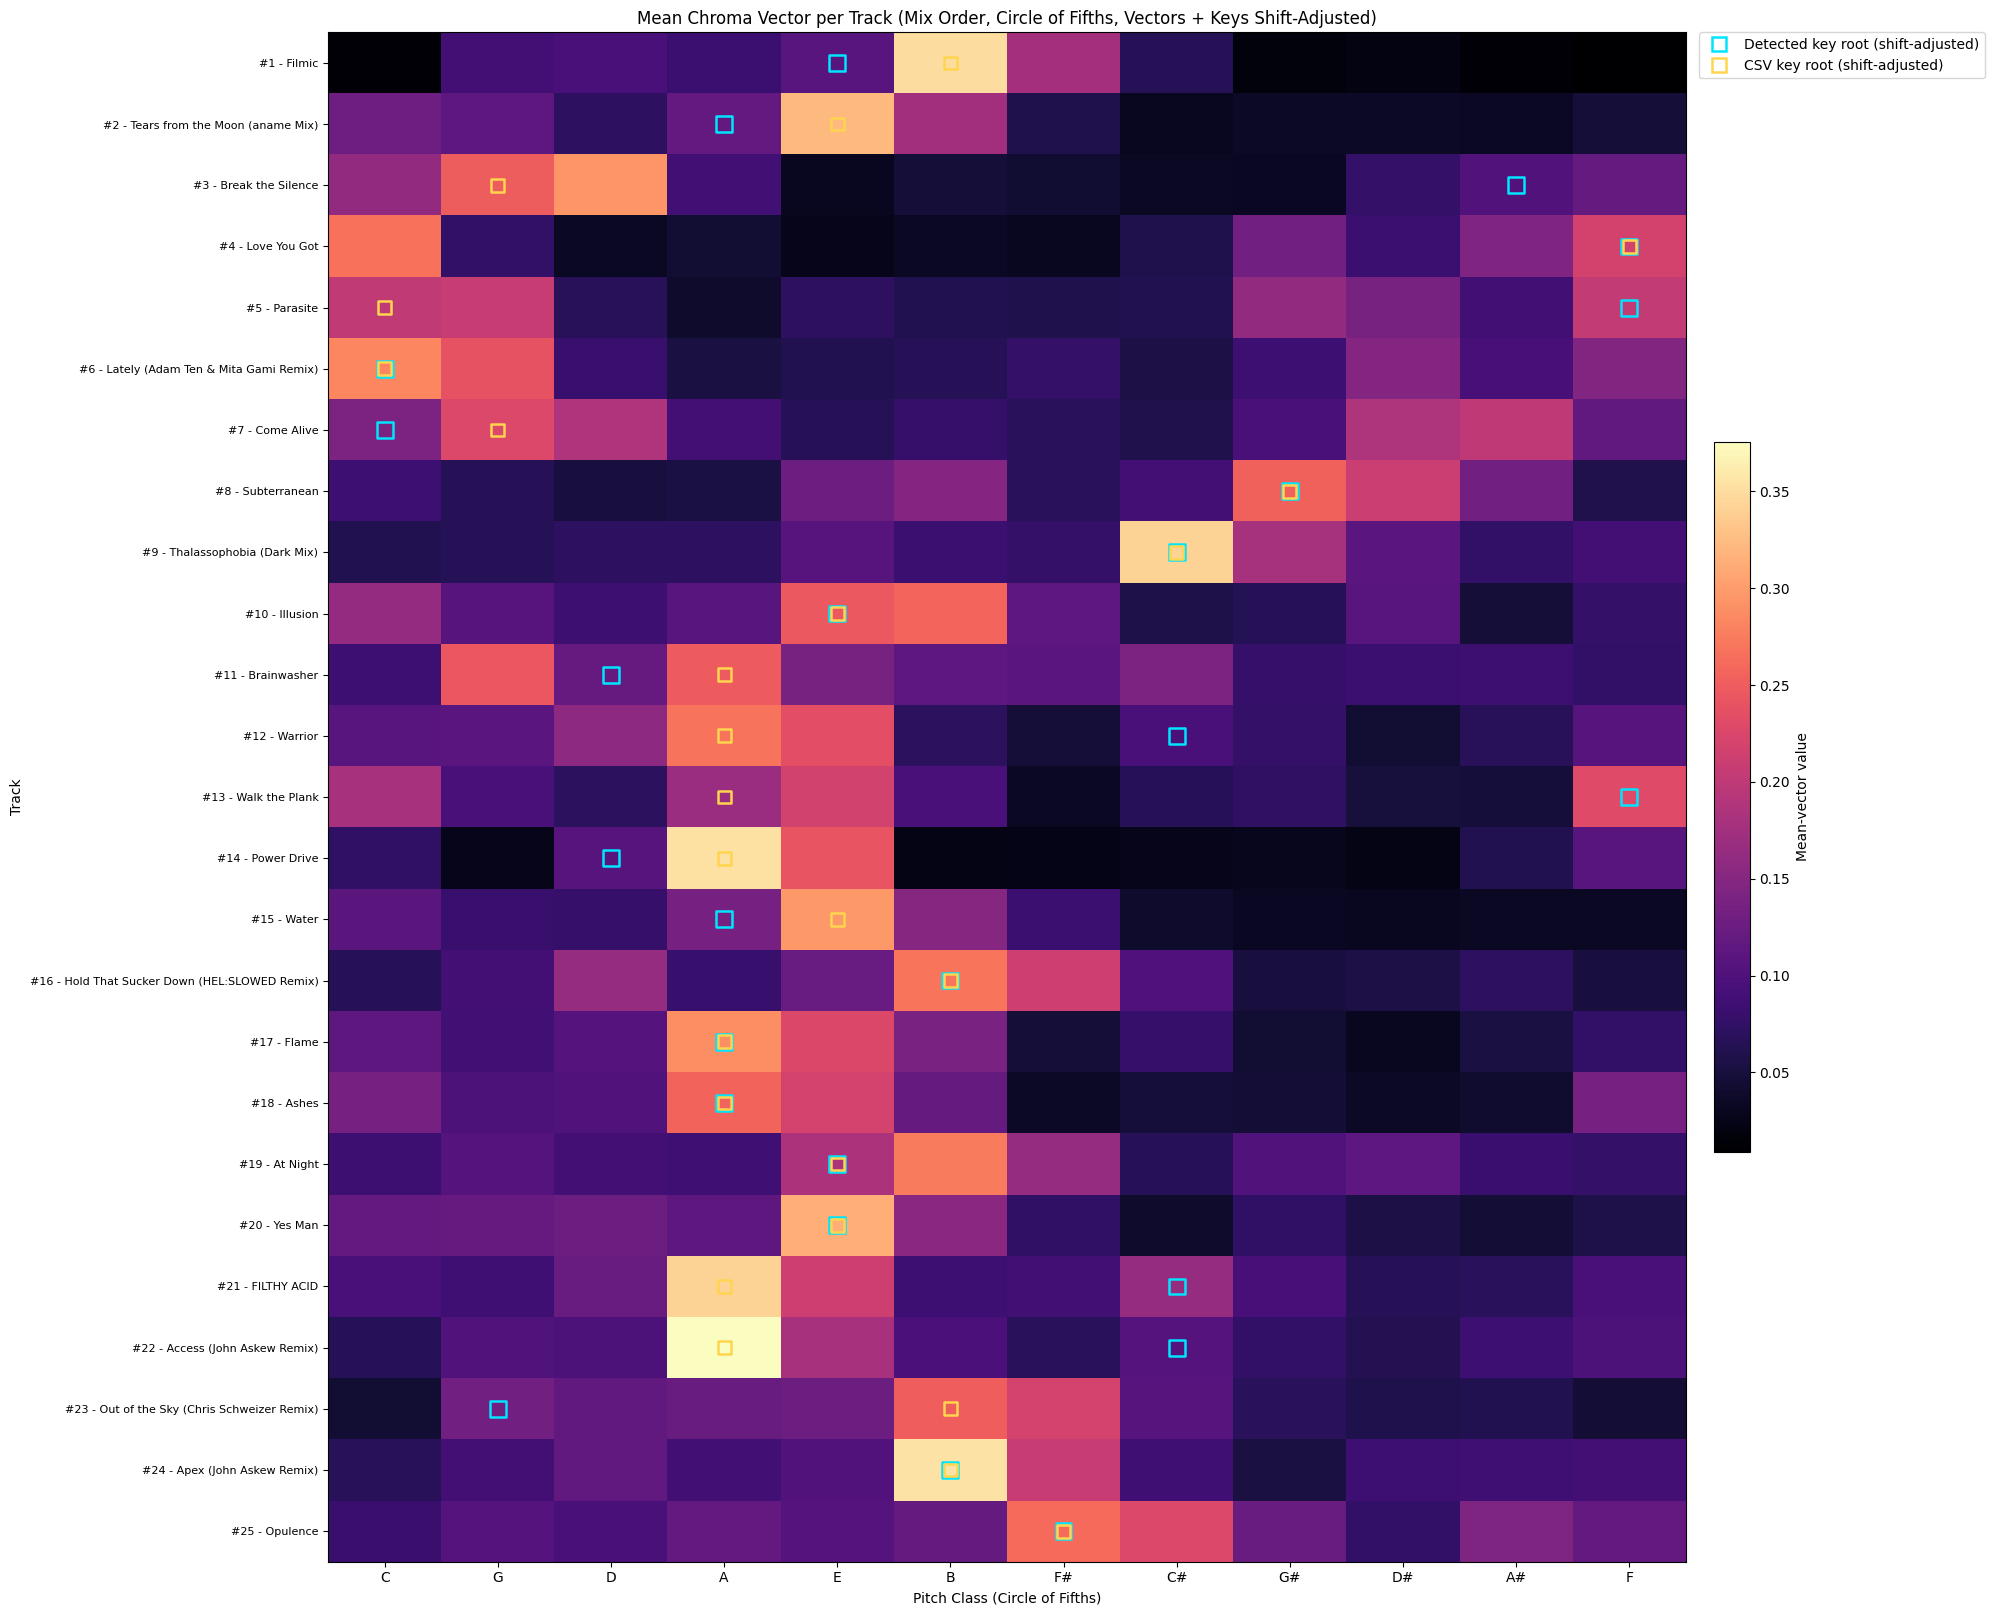

Saved plot: data/chroma_embeddings/chroma_mean_vectors_circle_of_fifths_shift_markers.png
Tracks visualized: 25
Saved detected-key table: data/chroma_embeddings/detected_keys_shift_adjusted_table.csv
Saved CSV-key table: data/chroma_embeddings/csv_keys_shift_adjusted_table.csv
Pandas display unavailable; CSV files saved above.


In [ ]:
CHROMA_DATA_DIR = PROJECT_ROOT / "data" / "chroma_embeddings"
TRACKLIST_CSV = PROJECT_ROOT / "music" / "aries-mix" / "aries_mix_tracks.csv"

if not TRACKLIST_CSV.exists():
    raise FileNotFoundError(f"Tracklist CSV not found: {TRACKLIST_CSV}")
if not CHROMA_DATA_DIR.exists():
    raise FileNotFoundError(f"Chroma embedding directory not found: {CHROMA_DATA_DIR}")

camelot_to_standard = {
    "1A": "G# minor",
    "2A": "D# minor",
    "3A": "A# minor",
    "4A": "F minor",
    "5A": "C minor",
    "6A": "G minor",
    "7A": "D minor",
    "8A": "A minor",
    "9A": "E minor",
    "10A": "B minor",
    "11A": "F# minor",
    "12A": "C# minor",
    "1B": "B major",
    "2B": "F# major",
    "3B": "C# major",
    "4B": "G# major",
    "5B": "D# major",
    "6B": "A# major",
    "7B": "F major",
    "8B": "C major",
    "9B": "G major",
    "10B": "D major",
    "11B": "A major",
    "12B": "E major",
}

pitch_labels_12 = ["A", "A#", "B", "C", "C#", "D", "D#", "E", "F", "F#", "G", "G#"]
semitone_labels = ["C", "C#", "D", "D#", "E", "F", "F#", "G", "G#", "A", "A#", "B"]
circle_of_fifths_labels = ["C", "G", "D", "A", "E", "B", "F#", "C#", "G#", "D#", "A#", "F"]

enharmonic_root_map = {
    "CB": "B",
    "DB": "C#",
    "EB": "D#",
    "FB": "E",
    "GB": "F#",
    "AB": "G#",
    "BB": "A#",
    "E#": "F",
    "B#": "C",
}


def normalize_root(root: str | None) -> str | None:
    if root is None:
        return None
    token = str(root).strip().upper().replace("♯", "#").replace("♭", "B")
    if not token or token in {"N", "NA", "N/A", "UNKNOWN", "NONE"}:
        return None
    token = enharmonic_root_map.get(token, token)
    if token in semitone_labels:
        return token
    return None


def shift_root(root: str | None, semitone_shift: int) -> str | None:
    normalized = normalize_root(root)
    if normalized is None:
        return None
    idx = semitone_labels.index(normalized)
    shifted_idx = (idx + int(semitone_shift)) % 12
    return semitone_labels[shifted_idx]


def convert_camelot_key(value: str) -> tuple[str | None, str | None, str]:
    if value is None:
        return None, None, "N/A"
    token = value.strip().upper()
    m = re.match(r"^(\d{1,2})([AB])$", token)
    if not m:
        return None, None, "N/A"
    normalized = f"{int(m.group(1))}{m.group(2)}"
    standard = camelot_to_standard.get(normalized)
    if standard is None:
        return None, None, "N/A"
    parts = standard.split()
    if len(parts) < 2:
        return None, None, standard
    root = normalize_root(parts[0])
    mode = parts[1].lower()
    return root, mode, standard


def format_key(root: str | None, mode: str | None) -> str:
    if root is None:
        return "N/A"
    if mode is None:
        return root
    return f"{root} {mode}"


with TRACKLIST_CSV.open("r", encoding="utf-8", newline="") as f:
    reader = csv.DictReader(f)
    csv_rows = list(reader)

ordered_rows = []
for row in csv_rows:
    tn = (row.get("track_number") or row.get("#") or "").strip()
    mp3_name = (row.get("mp3_name") or "").strip()
    title = (row.get("title") or "").strip() or Path(mp3_name).stem
    camelot = (row.get("key") or "").strip()
    key_shift_raw = (row.get("key shift") or "0").strip()

    if not tn or not mp3_name:
        continue
    try:
        track_num = int(tn)
    except ValueError:
        continue

    try:
        key_shift = int(float(key_shift_raw))
    except ValueError:
        key_shift = 0

    ordered_rows.append(
        {
            "track_num": track_num,
            "title": title,
            "mp3_name": mp3_name,
            "camelot": camelot,
            "key_shift": key_shift,
        }
    )

ordered_rows.sort(key=lambda x: x["track_num"])
if not ordered_rows:
    raise RuntimeError("No usable rows found in tracklist CSV.")

mean_vectors = []
track_labels = []
missing_embeddings = []

detected_table_rows = []
csv_table_rows = []

detected_shifted_roots = []
csv_shifted_roots = []

for row in ordered_rows:
    embedding_file = CHROMA_DATA_DIR / f"{Path(row['mp3_name']).stem}_chroma_embedding.json"
    if not embedding_file.exists():
        missing_embeddings.append(row["mp3_name"])
        continue

    with embedding_file.open("r", encoding="utf-8") as f:
        payload = json.load(f)

    embedding = np.asarray(payload.get("embedding", []), dtype=np.float32)
    chroma_bins = int(payload.get("chroma_bins", 12))
    if embedding.size < chroma_bins or chroma_bins <= 0:
        missing_embeddings.append(row["mp3_name"])
        continue

    if chroma_bins != 12:
        raise ValueError(f"This plot expects 12 chroma bins, got {chroma_bins} for {row['mp3_name']}")

    base_mean_vector = embedding[:chroma_bins].astype(np.float32)
    mean_vector_shifted = np.roll(base_mean_vector, int(row["key_shift"]))
    mean_vectors.append(mean_vector_shifted)
    label = f"#{row['track_num']} - {row['title']}"
    track_labels.append(label)

    # Detected key from embedding JSON
    key_est = payload.get("key_estimate", {})
    det_root_raw = normalize_root(key_est.get("key"))
    det_scale = str(key_est.get("scale", "unknown")).lower()
    det_strength = key_est.get("strength", None)
    det_root_shifted = shift_root(det_root_raw, row["key_shift"])
    detected_shifted_roots.append(det_root_shifted)

    if isinstance(det_strength, (int, float)):
        det_strength_txt = f"{float(det_strength):.3f}"
    else:
        det_strength_txt = "N/A"

    detected_table_rows.append(
        {
            "track": label,
            "key_shift_semitones": row["key_shift"],
            "detected_raw": format_key(det_root_raw, det_scale),
            "detected_strength": det_strength_txt,
            "detected_shifted": format_key(det_root_shifted, det_scale),
        }
    )

    # CSV key from Camelot, shifted by key shift
    csv_root_raw, csv_mode, csv_standard = convert_camelot_key(row["camelot"])
    csv_root_shifted = shift_root(csv_root_raw, row["key_shift"])
    csv_shifted_roots.append(csv_root_shifted)

    csv_table_rows.append(
        {
            "track": label,
            "key_shift_semitones": row["key_shift"],
            "csv_camelot": row["camelot"],
            "csv_standard_raw": csv_standard,
            "csv_standard_shifted": format_key(csv_root_shifted, csv_mode),
        }
    )

if not mean_vectors:
    raise RuntimeError("No chroma embedding JSON files were matched from CSV rows.")

mean_matrix = np.vstack(mean_vectors)
label_to_idx = {label: idx for idx, label in enumerate(pitch_labels_12)}
reorder_idx = [label_to_idx[label] for label in circle_of_fifths_labels]
mean_matrix_fifths = mean_matrix[:, reorder_idx]

n_tracks = mean_matrix_fifths.shape[0]
fig, ax = plt.subplots(figsize=(20, max(10, 0.45 * n_tracks + 5)))
im = ax.imshow(mean_matrix_fifths, aspect="auto", cmap="magma", interpolation="nearest")

ax.set_title("Mean Chroma Vector per Track (Mix Order, Circle of Fifths, Vectors + Keys Shift-Adjusted)")
ax.set_xlabel("Pitch Class (Circle of Fifths)")
ax.set_ylabel("Track")
ax.set_xticks(np.arange(12))
ax.set_xticklabels(circle_of_fifths_labels)
ax.set_yticks(np.arange(n_tracks))
ax.set_yticklabels(track_labels, fontsize=8)

# Overlay square markers at shifted key roots
for i, root in enumerate(detected_shifted_roots):
    if root in circle_of_fifths_labels:
        x = circle_of_fifths_labels.index(root)
        ax.scatter(
            x,
            i,
            marker="s",
            s=130,
            facecolors="none",
            edgecolors="#00E5FF",
            linewidths=1.8,
            zorder=5,
        )

for i, root in enumerate(csv_shifted_roots):
    if root in circle_of_fifths_labels:
        x = circle_of_fifths_labels.index(root)
        ax.scatter(
            x,
            i,
            marker="s",
            s=85,
            facecolors="none",
            edgecolors="#FFD54F",
            linewidths=1.8,
            zorder=6,
        )

legend_handles = [
    Line2D([0], [0], marker="s", color="none", markerfacecolor="none", markeredgecolor="#00E5FF", markeredgewidth=1.8, markersize=10, label="Detected key root (shift-adjusted)"),
    Line2D([0], [0], marker="s", color="none", markerfacecolor="none", markeredgecolor="#FFD54F", markeredgewidth=1.8, markersize=10, label="CSV key root (shift-adjusted)"),
]
ax.legend(handles=legend_handles, loc="upper left", bbox_to_anchor=(1.01, 1.0), borderaxespad=0.0)

cb = fig.colorbar(im, ax=ax, fraction=0.025, pad=0.02)
cb.set_label("Mean-vector value")

output_plot = CHROMA_DATA_DIR / "chroma_mean_vectors_circle_of_fifths_shift_markers.png"
fig.tight_layout()
fig.savefig(output_plot, dpi=220, bbox_inches="tight")
plt.show()

print(f"Saved output: plot: {to_project_relpath(output_plot)}")
print(f"Tracks visualized: {n_tracks}")
if missing_embeddings:
    print(f"Missing/invalid chroma embedding files ({len(missing_embeddings)}):")
    for name in missing_embeddings:
        print(f"  - {name}")

# Separate tables (not embedded in the figure)
detected_csv_path = CHROMA_DATA_DIR / "detected_keys_shift_adjusted_table.csv"
csv_keys_csv_path = CHROMA_DATA_DIR / "csv_keys_shift_adjusted_table.csv"

with detected_csv_path.open("w", encoding="utf-8", newline="") as f:
    writer = csv.DictWriter(
        f,
        fieldnames=["track", "key_shift_semitones", "detected_raw", "detected_strength", "detected_shifted"],
    )
    writer.writeheader()
    writer.writerows(detected_table_rows)

with csv_keys_csv_path.open("w", encoding="utf-8", newline="") as f:
    writer = csv.DictWriter(
        f,
        fieldnames=["track", "key_shift_semitones", "csv_camelot", "csv_standard_raw", "csv_standard_shifted"],
    )
    writer.writeheader()
    writer.writerows(csv_table_rows)

print(f"Saved output: detected-key table: {to_project_relpath(detected_csv_path)}")
print(f"Saved output: CSV-key table: {to_project_relpath(csv_keys_csv_path)}")

# Optional rich display in notebook
try:
    import pandas as pd
    from IPython.display import display

    df_detected = pd.DataFrame(detected_table_rows)
    df_csv = pd.DataFrame(csv_table_rows)

    print("\nDetected key table:")
    display(df_detected)
    print("\nCSV key table:")
    display(df_csv)
except Exception:
    print("Pandas display unavailable; CSV files saved above.")







## Harmonic Compatibility Matrix

Compute pairwise harmonic compatibility across `aries-mix`
using the fifth-aware kernel on 12-D pitch-class vectors.

This section now shows both:
- raw compatibility
- normalized compatibility (self-similarity = 1)



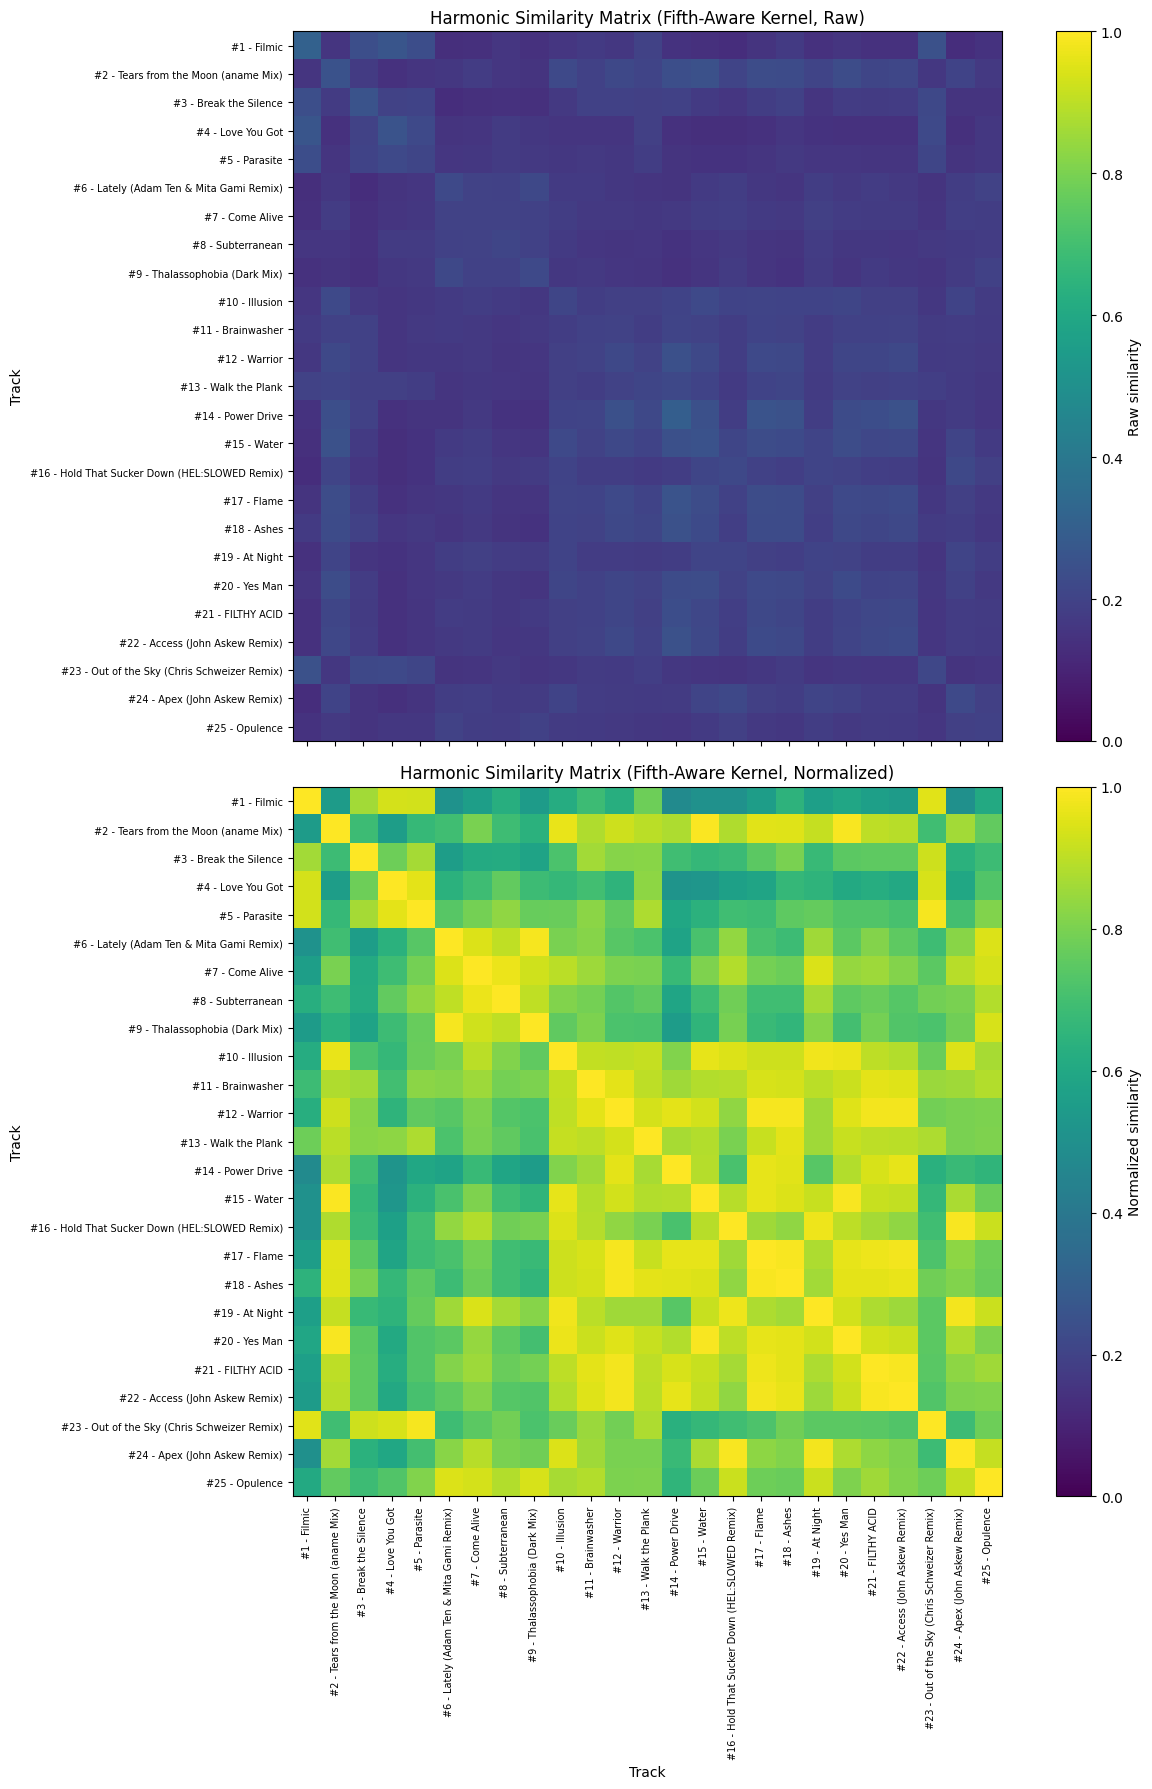

Saved plot: data/chroma_embeddings/harmonic_similarity_fifth_aware_matrix.png
Saved matrix data: data/chroma_embeddings/harmonic_similarity_fifth_aware_matrix.npz
Tracks included: 25


In [14]:
TRACKLIST_CSV = PROJECT_ROOT / "music" / "aries-mix" / "aries_mix_tracks.csv"
CHROMA_DATA_DIR = PROJECT_ROOT / "data" / "chroma_embeddings"

if not TRACKLIST_CSV.exists():
    raise FileNotFoundError(f"Tracklist CSV not found: {TRACKLIST_CSV}")
if not CHROMA_DATA_DIR.exists():
    raise FileNotFoundError(f"Chroma embedding directory not found: {CHROMA_DATA_DIR}")

# Essentia HPCP/chroma bin order used in this project
pitch_order_a = ["A", "A#", "B", "C", "C#", "D", "D#", "E", "F", "F#", "G", "G#"]
pitch_order_c = list(PITCH_CLASS_C_ORDER)
a_to_c_idx = [pitch_order_a.index(label) for label in pitch_order_c]

with TRACKLIST_CSV.open("r", encoding="utf-8", newline="") as f:
    reader = csv.DictReader(f)
    csv_rows = list(reader)

ordered_rows = []
for row in csv_rows:
    tn = (row.get("track_number") or row.get("#") or "").strip()
    mp3_name = (row.get("mp3_name") or "").strip()
    title = (row.get("title") or "").strip() or Path(mp3_name).stem
    if not tn or not mp3_name:
        continue
    try:
        track_num = int(tn)
    except ValueError:
        continue
    ordered_rows.append({"track_num": track_num, "title": title, "mp3_name": mp3_name})

ordered_rows.sort(key=lambda x: x["track_num"])
if not ordered_rows:
    raise RuntimeError("No usable rows found in tracklist CSV.")

track_labels = []
vectors_c = []
missing = []

for row in ordered_rows:
    embedding_file = CHROMA_DATA_DIR / f"{Path(row['mp3_name']).stem}_chroma_embedding.json"
    if not embedding_file.exists():
        missing.append(row["mp3_name"])
        continue

    with embedding_file.open("r", encoding="utf-8") as f:
        payload = json.load(f)

    embedding = np.asarray(payload.get("embedding", []), dtype=np.float32)
    chroma_bins = int(payload.get("chroma_bins", 12))

    if chroma_bins != 12 or embedding.size < 12:
        missing.append(row["mp3_name"])
        continue

    # Use the first 12 dims (pitch-class mean vector) and reorder to [C..B]
    vec_a = embedding[:12].astype(np.float32)
    vec_c = vec_a[a_to_c_idx]

    vectors_c.append(vec_c)
    track_labels.append(f"#{row['track_num']} - {row['title']}")

if not vectors_c:
    raise RuntimeError("No valid 12-D pitch-class vectors were found.")

X = np.vstack(vectors_c).astype(np.float32)
K = build_fifth_kernel(exact_weight=1.0, first_fifth_weight=0.4, second_fifth_weight=0.15, other_weight=0.0)
S = pairwise_fifth_aware_similarity_matrix(X, kernel=K)

# Kernel-normalized similarity so self-similarity is 1.0 (for non-zero vectors)
diag = np.diag(S).astype(np.float32)
den = np.sqrt(np.outer(diag, diag)).astype(np.float32)
S_norm = np.divide(S, den, out=np.zeros_like(S), where=den > 0)
valid_diag = diag > 0
S_norm[np.diag_indices_from(S_norm)] = np.where(valid_diag, 1.0, 0.0)

fig, (ax_raw, ax_norm) = plt.subplots(2, 1, figsize=(14, 18), sharex=True, sharey=True)

im_raw = ax_raw.imshow(S, cmap="viridis", vmin=0.0, vmax=max(1.0, float(np.max(S))))
ax_raw.set_title("Harmonic Similarity Matrix (Fifth-Aware Kernel, Raw)")
ax_raw.set_ylabel("Track")
ax_raw.set_xticks(np.arange(len(track_labels)))
ax_raw.set_yticks(np.arange(len(track_labels)))
ax_raw.set_xticklabels(track_labels, rotation=90, fontsize=7)
ax_raw.set_yticklabels(track_labels, fontsize=7)
ax_raw.tick_params(axis="x", labelbottom=False)
fig.colorbar(im_raw, ax=ax_raw, fraction=0.046, pad=0.04, label="Raw similarity")

im_norm = ax_norm.imshow(S_norm, cmap="viridis", vmin=0.0, vmax=1.0)
ax_norm.set_title("Harmonic Similarity Matrix (Fifth-Aware Kernel, Normalized)")
ax_norm.set_xlabel("Track")
ax_norm.set_ylabel("Track")
ax_norm.set_xticks(np.arange(len(track_labels)))
ax_norm.set_yticks(np.arange(len(track_labels)))
ax_norm.set_xticklabels(track_labels, rotation=90, fontsize=7)
ax_norm.set_yticklabels(track_labels, fontsize=7)
fig.colorbar(im_norm, ax=ax_norm, fraction=0.046, pad=0.04, label="Normalized similarity")

fig.tight_layout()

plot_path = CHROMA_DATA_DIR / "harmonic_similarity_fifth_aware_matrix.png"
fig.savefig(plot_path, dpi=220)
plt.show()

matrix_path = CHROMA_DATA_DIR / "harmonic_similarity_fifth_aware_matrix.npz"
np.savez_compressed(
    matrix_path,
    labels=np.array(track_labels),
    similarity_matrix=S,
    similarity_matrix_normalized=S_norm,
    kernel=K,
    pitch_order=np.array(pitch_order_c),
)

print(f"Saved output: plot: {to_project_relpath(plot_path)}")
print(f"Saved output: matrix data: {to_project_relpath(matrix_path)}")
print(f"Tracks included: {len(track_labels)}")
if missing:
    print(f"Missing/invalid embedding files ({len(missing)}):")
    for name in missing:
        print(f"  - {name}")




